# GPU-Only Training: RF, XGBoost, CatBoost, LightGBM

This notebook trains only four models with GPU acceleration and no cuML:
- Random Forest (GPU via XGBoost RF)
- XGBoost (GPU)
- CatBoost (GPU)
- LightGBM (GPU)

In [1]:
# Optional: install missing packages in the active kernel
%pip install -q numpy pandas scipy scikit-learn xgboost catboost lightgbm imbalanced-learn venn-abers shap lime

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import time
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.sparse import hstack
from imblearn.over_sampling import ADASYN, SMOTE
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from xgboost import XGBClassifier, XGBRFClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

print(f"Python executable: {sys.executable}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '<not set>')}")

try:
    smi = subprocess.check_output(['nvidia-smi'], text=True, stderr=subprocess.STDOUT)
    print("nvidia-smi detected.")
    print("\n".join(smi.splitlines()[:8]))
except Exception as e:
    raise RuntimeError(f"GPU check failed (nvidia-smi unavailable): {e}")

warnings.filterwarnings('ignore')

EPOCHS = 500
N_JOBS = -1

print("xgboost version:", __import__('xgboost').__version__)
print("catboost version:", __import__('catboost').__version__)
print("lightgbm version:", __import__('lightgbm').__version__)

KeyboardInterrupt: 

## Rerun Order

If you change preprocessing or tuning settings, rerun from the imports/config cell onward. The shortest safe path is:
1. imports and global config
2. data loading and preprocessing
3. split and encoding
4. model utilities and search spaces
5. recall-priority training
6. accuracy-priority training
7. metric summary and explainability

In [ ]:
PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find a merged dataset CSV near this notebook.')

df = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Raw shape: {df.shape}")

lower_to_col = {c.lower(): c for c in df.columns}
target_candidates = ['target', 'label', 'outcome', 'hypertension', 'htn', 'class', 'y']
target_col = next((lower_to_col[c] for c in target_candidates if c in lower_to_col), None)

sbp_col = next((c for c in df.columns if 'sbp' in c.lower() or 'systolic' in c.lower()), None)
dbp_col = next((c for c in df.columns if 'dbp' in c.lower() or 'diastolic' in c.lower()), None)

# Hypertension definition: SBP >= 130 OR DBP >= 80.
if sbp_col and dbp_col:
    target_col = '__derived_hypertension_130_80__'
    df[target_col] = ((pd.to_numeric(df[sbp_col], errors='coerce') >= 130) | (pd.to_numeric(df[dbp_col], errors='coerce') >= 80)).astype(int)
    print(f"Target derived from {sbp_col}/{dbp_col} with rule: SBP >= 130 OR DBP >= 80")
elif target_col is None:
    raise ValueError('No binary target found and could not derive target from SBP/DBP columns.')

# Leakage guard: remove raw BP columns immediately after target creation.
drop_leakage = [c for c in [sbp_col, dbp_col] if c is not None and c in df.columns]
if drop_leakage:
    df = df.drop(columns=drop_leakage)
    print(f"Leakage guard dropped: {drop_leakage}")

# Remove administrative identifiers.
id_drop_cols = [
    c for c in df.columns
    if c.lower() in {'hhnum', 'member_code', 'id', 'record_id'}
    or c.lower().endswith('_id')
    or c.lower().startswith('id_')
]
if id_drop_cols:
    df = df.drop(columns=id_drop_cols)
    print(f"Dropped identifier/admin columns: {len(id_drop_cols)}")

# Filter non-adult and pregnancy/lactation rows when columns exist.
age_col = next((c for c in df.columns if c.lower() in {'age', 'age_years'} or 'age' == c.lower().replace(' ', '_')), None)
if age_col is not None:
    before = len(df)
    df = df[df[age_col].fillna(-1) >= 18].copy()
    print(f"Adult filter using {age_col}: {before} -> {len(df)}")

preg_col = next((c for c in df.columns if 'preg' in c.lower()), None)
if preg_col is not None:
    before = len(df)
    preg_mask = df[preg_col].astype(str).str.lower().isin(['1', 'true', 'yes', 'pregnant'])
    df = df[~preg_mask].copy()
    print(f"Pregnancy filter using {preg_col}: {before} -> {len(df)}")

lact_col = next((c for c in df.columns if 'lact' in c.lower() or 'breastfeed' in c.lower()), None)
if lact_col is not None:
    before = len(df)
    lact_mask = df[lact_col].astype(str).str.lower().isin(['1', 'true', 'yes', 'lactating'])
    df = df[~lact_mask].copy()
    print(f"Lactation filter using {lact_col}: {before} -> {len(df)}")

# Feature engineering: BMI and WHR when source columns are available.
weight_col = next((c for c in df.columns if 'weight' in c.lower()), None)
height_col = next((c for c in df.columns if 'height' in c.lower()), None)
waist_col = next((c for c in df.columns if 'waist' in c.lower()), None)
hip_col = next((c for c in df.columns if 'hip' in c.lower()), None)

if weight_col and height_col and 'BMI' not in df.columns:
    h = pd.to_numeric(df[height_col], errors='coerce')
    w = pd.to_numeric(df[weight_col], errors='coerce')
    h_m = np.where(h > 3, h / 100.0, h)
    df['BMI'] = w / np.where(h_m > 0, h_m ** 2, np.nan)

if waist_col and hip_col and 'WHR' not in df.columns:
    waist = pd.to_numeric(df[waist_col], errors='coerce')
    hip = pd.to_numeric(df[hip_col], errors='coerce')
    df['WHR'] = waist / np.where(hip > 0, hip, np.nan)

# Lifestyle ordinal bins (robust fallback when source columns exist).
smoke_col = next((c for c in df.columns if 'smok' in c.lower()), None)
if smoke_col and 'Smoking_Level' not in df.columns:
    smoke_raw = pd.to_numeric(df[smoke_col], errors='coerce').fillna(0)
    df['Smoking_Level'] = pd.cut(
        smoke_raw,
        bins=[-np.inf, 0, 5, 20, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(float)

alcohol_col = next((c for c in df.columns if 'alcohol' in c.lower() or 'drink' in c.lower()), None)
if alcohol_col and 'Alcohol_Level' not in df.columns:
    alc_raw = pd.to_numeric(df[alcohol_col], errors='coerce').fillna(0)
    df['Alcohol_Level'] = pd.cut(
        alc_raw,
        bins=[-np.inf, 0, 1, 3, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(float)

y = df[target_col]
X = df.drop(columns=[target_col])

if y.dtype == object:
    y = y.astype(str).str.strip().str.lower()
    map_bin = {'yes': 1, 'no': 0, 'true': 1, 'false': 0, '1': 1, '0': 0}
    if set(y.unique()).issubset(set(map_bin.keys())):
        y = y.map(map_bin)

y = pd.Series(y).astype(float)
if y.nunique(dropna=True) != 2:
    raise ValueError(f'Target must be binary. Found {y.nunique(dropna=True)} unique values in {target_col}.')

valid = y.notna()
X = X.loc[valid].copy()
y = y.loc[valid].astype(int)

X = X.replace([np.inf, -np.inf], np.nan)

# Sentinel value recoding: repeated-digit NHANES-style sentinels -> NaN.
sentinel_numeric = {7, 9}
for digit in (7, 8, 9):
    for length in range(2, 9):
        sentinel_numeric.add(int(str(digit) * length))
sentinel_string = {str(value) for value in sentinel_numeric}
missing_before = int(X.isna().sum().sum())
for col in X.columns:
    series = X[col]
    if pd.api.types.is_numeric_dtype(series):
        X.loc[series.isin(sentinel_numeric), col] = np.nan
    else:
        series_str = series.astype(str).str.strip()
        X.loc[series_str.isin(sentinel_string), col] = np.nan
missing_after = int(X.isna().sum().sum())
print(f"Sentinel recoding added {missing_after - missing_before} NaN values")

# Categorical regrouping for low-cardinality coded features after sentinel cleanup.
for col in X.columns:
    nunique = X[col].nunique(dropna=True)
    if 3 <= nunique <= 20:
        vc = X[col].value_counts(normalize=True, dropna=True)
        rare_levels = vc[vc < 0.01].index
        if len(rare_levels) > 0:
            X[col] = X[col].apply(lambda v: 'Other' if pd.notna(v) and v in set(rare_levels) else v)

numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Target column: {target_col}")
print(f"Prepared samples: {len(X)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Loaded: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Raw shape: (151189, 80)
Target derived from Ave_SBP/Ave_DBP with rule: SBP >= 130 OR DBP >= 80
Leakage guard dropped: ['Ave_SBP', 'Ave_DBP']
Dropped identifier/admin columns: 2
Adult filter using age: 151189 -> 93429
Pregnancy filter using mos_preg: 93429 -> 93429
Lactation filter using mos_lactation: 93429 -> 93429
Sentinel recoding added 178743 NaN values
Target column: __derived_hypertension_130_80__
Prepared samples: 93429
Numeric features: 75
Categorical features: 5


In [ ]:

# Sentinel value recoding: NHANES-style sentinels (7s=refused, 9s=don't know) → NaN
# This is applied to ALL columns, not just a predefined list
sentinel_mapping = {7: np.nan, 9: np.nan}
for digit in (7, 8, 9):
    for length in range(2, 9):
        sentinel_mapping[int(str(digit) * length)] = np.nan
        sentinel_mapping[str(int(str(digit) * length))] = np.nan

print("\n=== SENTINEL VALUE RECODING (ALL COLUMNS) ===")
sentinel_count = 0
recoded_cols = []

for col in df.columns:
    if col == target_col:  # Skip the target column
        continue
    
    before = df[col].isna().sum()
    df[col] = df[col].replace(sentinel_mapping)
    after = df[col].isna().sum()
    
    if after > before:
        recoded = (after - before)
        sentinel_count += recoded
        recoded_cols.append((col, recoded))
        if recoded <= 100:  # Only print details if not too many
            print(f"  {col}: recoded {recoded} sentinel(s) to NaN")
        else:
            print(f"  {col}: recoded {recoded} sentinel(s) to NaN [LARGE]")

if sentinel_count > 0:
    print(f"\nTOTAL: {sentinel_count} sentinel values recoded across {len(recoded_cols)} columns")
    print(f"Recoded columns: {[col for col, _ in recoded_cols[:10]]}")
else:
    print("  No sentinel values found - data may be pre-cleaned")



=== SENTINEL VALUE RECODING (ALL COLUMNS) ===
  ever_smk: recoded 5135 sentinel(s) to NaN [LARGE]
  strrec: recoded 981 sentinel(s) to NaN [LARGE]
  smoke_status: recoded 11 sentinel(s) to NaN
  regcode: recoded 9721 sentinel(s) to NaN [LARGE]
  psurec: recoded 1443 sentinel(s) to NaN [LARGE]
  psc: recoded 43588 sentinel(s) to NaN [LARGE]
  provcode: recoded 268 sentinel(s) to NaN [LARGE]
  age: recoded 6 sentinel(s) to NaN
  drnk_30d_num: recoded 16703 sentinel(s) to NaN [LARGE]
  drnk_30days: recoded 13093 sentinel(s) to NaN [LARGE]
  current_smoking: recoded 11 sentinel(s) to NaN
  con_alcohol: recoded 9619 sentinel(s) to NaN [LARGE]
  binge_drinking: recoded 17062 sentinel(s) to NaN [LARGE]
  alcohol_status: recoded 91 sentinel(s) to NaN
  alcohol: recoded 62 sentinel(s) to NaN
  fg6: recoded 74 sentinel(s) to NaN
  fg7: recoded 53 sentinel(s) to NaN
  fg8: recoded 7 sentinel(s) to NaN
  fg9: recoded 6 sentinel(s) to NaN
  Total_Calcium: recoded 2 sentinel(s) to NaN
  fg5: recode

  strrec_anthro: recoded 981 sentinel(s) to NaN [LARGE]
  regcode_anthro: recoded 9721 sentinel(s) to NaN [LARGE]
  psurec_anthro: recoded 1443 sentinel(s) to NaN [LARGE]
  psc_anthro: recoded 43226 sentinel(s) to NaN [LARGE]
  provcode_anthro: recoded 268 sentinel(s) to NaN [LARGE]
  mos_preg: recoded 362 sentinel(s) to NaN [LARGE]
  age_anthro: recoded 6 sentinel(s) to NaN
  hip: recoded 300 sentinel(s) to NaN [LARGE]
  anthro_group: recoded 1410 sentinel(s) to NaN [LARGE]
  agemos: recoded 15 sentinel(s) to NaN

TOTAL: 178743 sentinel values recoded across 57 columns
Recoded columns: ['ever_smk', 'strrec', 'smoke_status', 'regcode', 'psurec', 'psc', 'provcode', 'age', 'drnk_30d_num', 'drnk_30days']


In [ ]:

# Diagnostic: Identify categorical data and sentinel values in raw df
print("=" * 80)
print("COMPREHENSIVE DATA TYPE AND SENTINEL ANALYSIS")
print("=" * 80)

print(f"\nDataFrame shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

# Identify which columns might be categorical
print("\n--- Columns by dtype ---")
dtype_groups = df.dtypes.value_counts()
print(dtype_groups)

print("\n--- Columns with object dtype ---")
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Found {len(object_cols)} object columns: {object_cols[:10]}")

if object_cols:
    print("\n--- Unique value counts for object columns ---")
    for col in object_cols[:10]:  # Show first 10
        n_unique = df[col].nunique()
        print(f"{col}: {n_unique} unique values")
        unique_vals = sorted([str(v) for v in df[col].dropna().unique()])
        print(f"  Values: {unique_vals[:15]}")  # Show first 15

# Check numeric columns for coded values (likely sentinels)
print("\n--- Numeric columns with small cardinality (potential coded categoricals) ---")
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols:
    n_unique = df[col].nunique(dropna=True)
    if n_unique <= 20:  # Low cardinality numeric = likely categorical
        unique_sorted = sorted(df[col].dropna().unique())
        print(f"{col}: {n_unique} unique values: {unique_sorted}")


COMPREHENSIVE DATA TYPE AND SENTINEL ANALYSIS

DataFrame shape: (93429, 81)
Total columns: 81

--- Columns by dtype ---
float64    76
int64       5
Name: count, dtype: int64

--- Columns with object dtype ---
Found 0 object columns: []

--- Numeric columns with small cardinality (potential coded categoricals) ---
ever_smk: 6 unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
smoke_status: 3 unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
sex: 2 unique values: [np.int64(1), np.int64(2)]
regcode: 15 unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(41.0), np.float64(42.0)]
psc: 11 unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.fl

## Exploratory Data Analysis

This section creates paper-ready figures and summary tables from the cleaned pre-split dataset.

,metric,value
0,rows,9.342900e+04
1,columns,8.100000e+01
2,numeric_features,7.500000e+01
3,categorical_features,5.000000e+00
4,target_prevalence,5.097000e-01
5,missing_cells,3.879916e+06
6,missing_rate,5.127000e-01


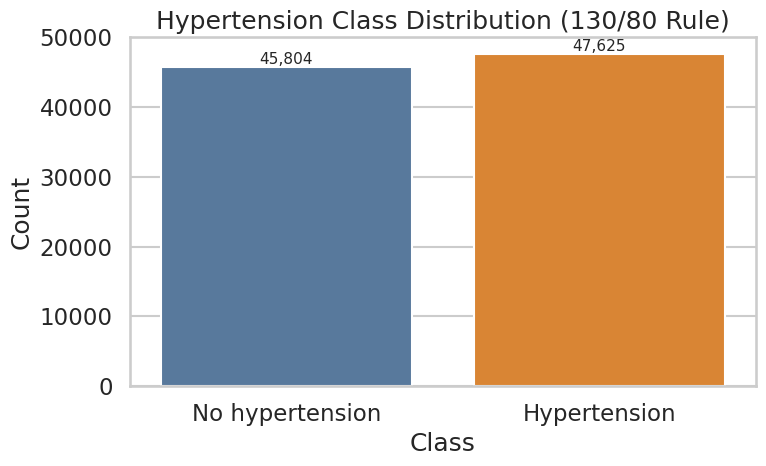

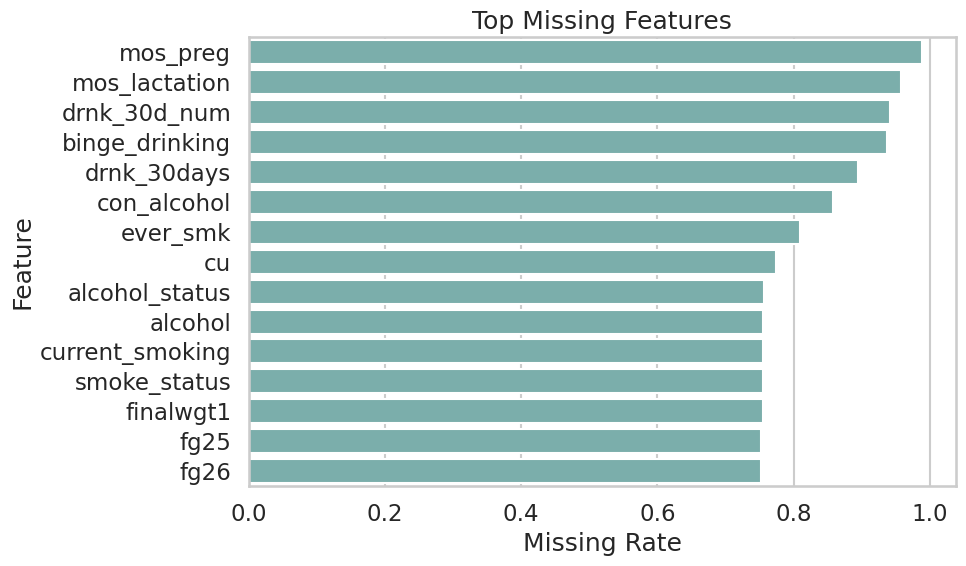

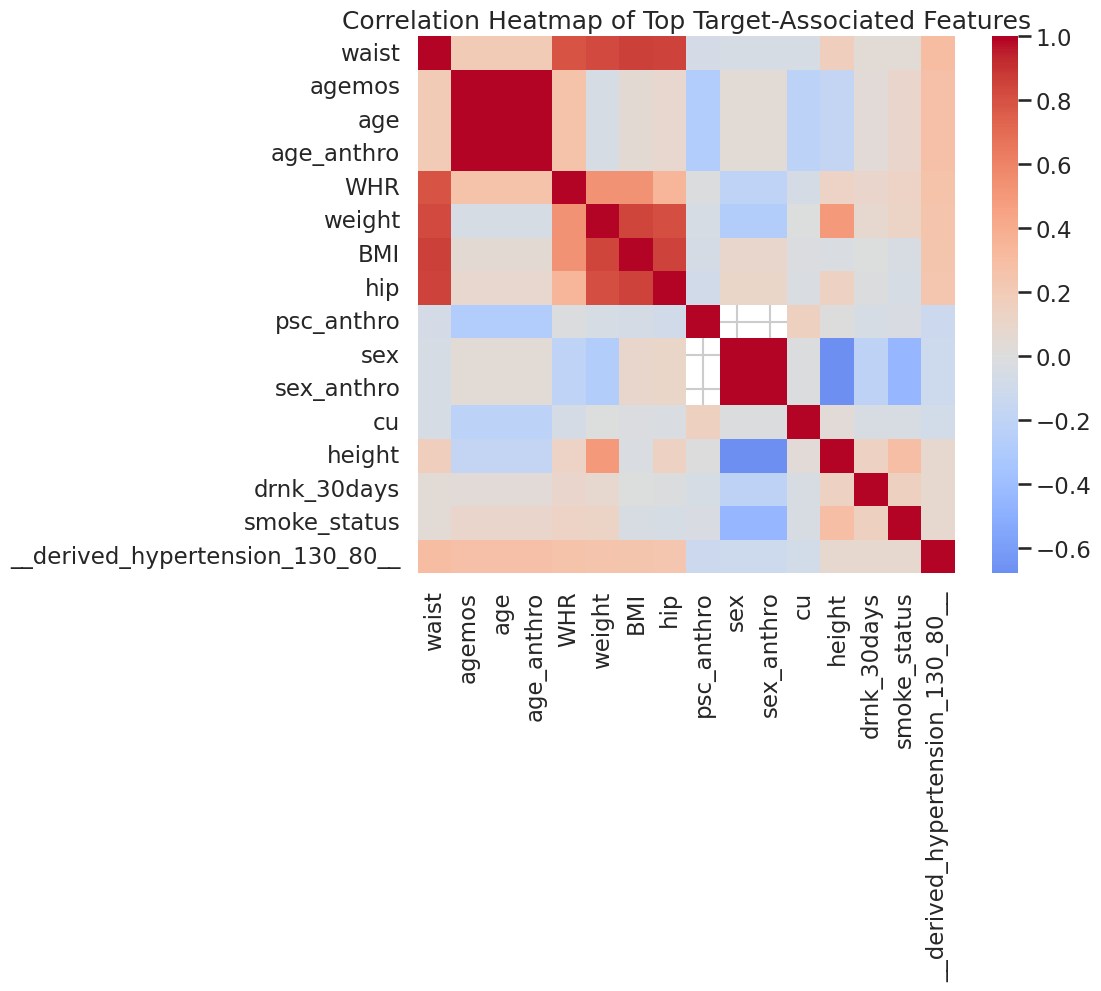

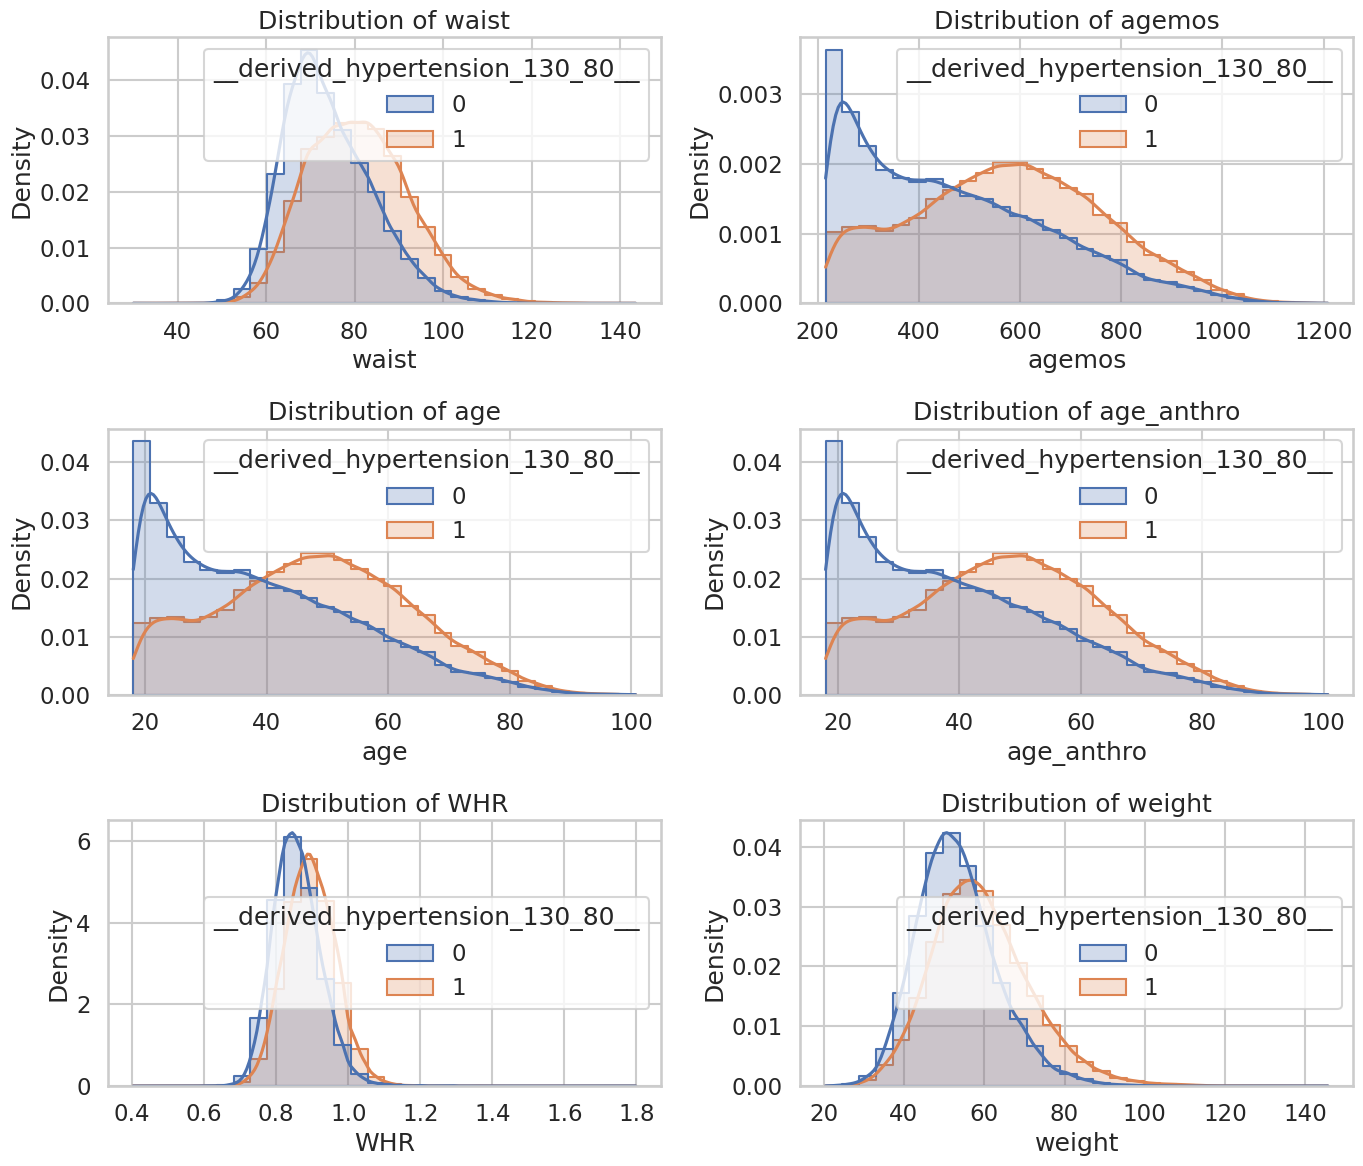

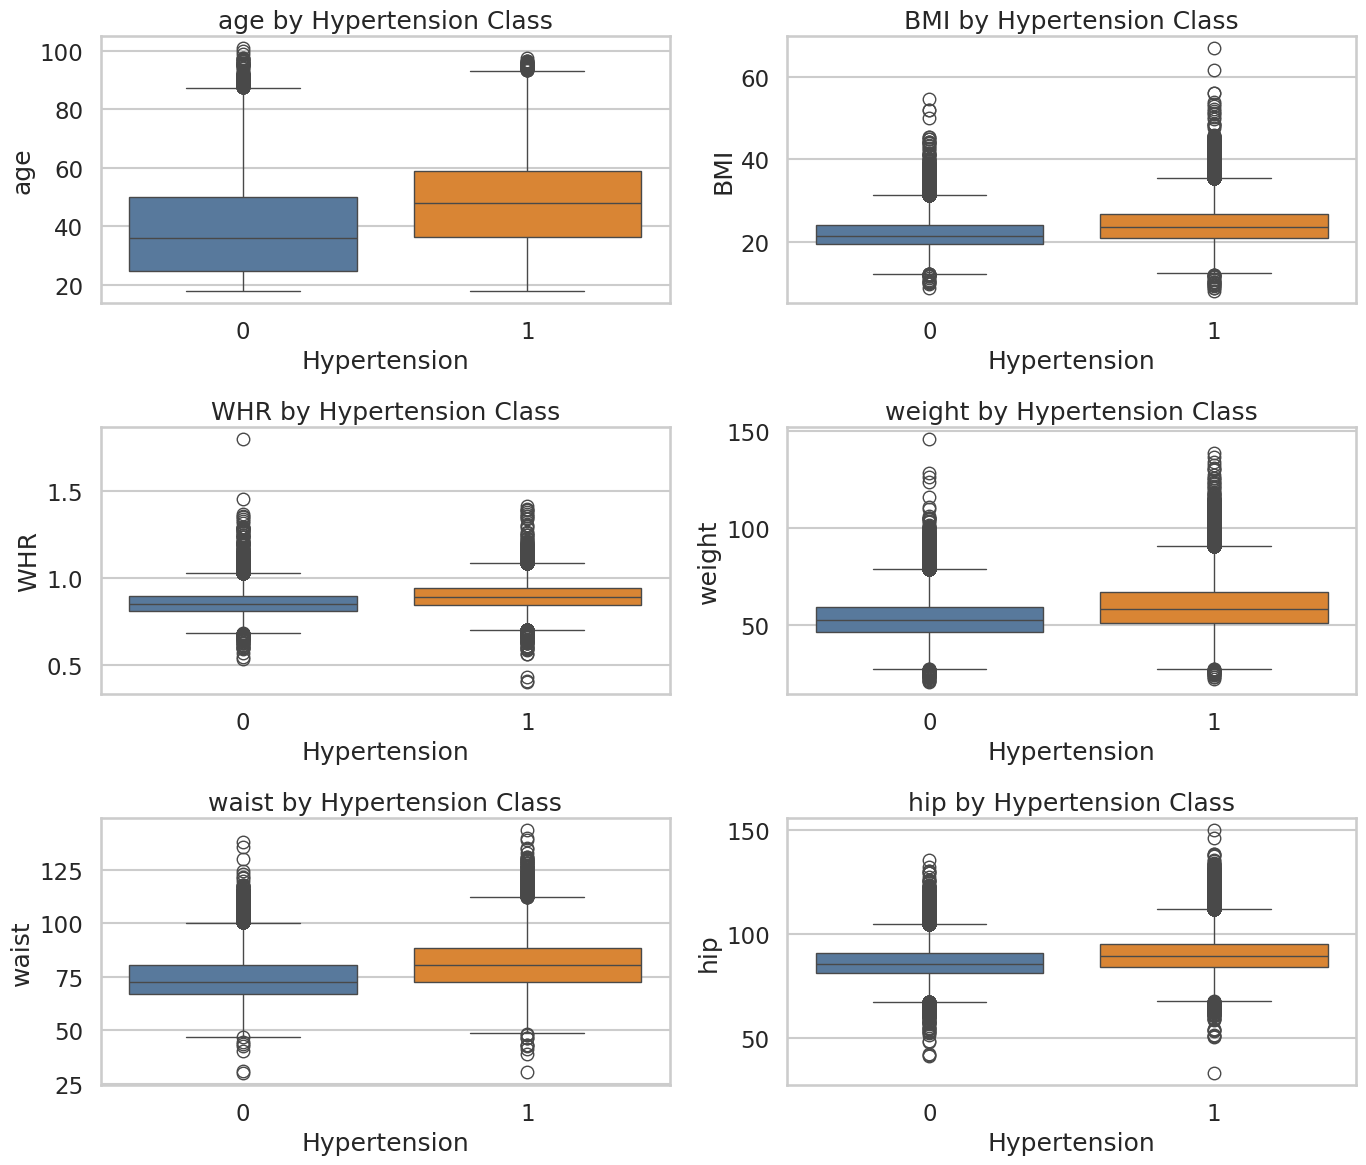

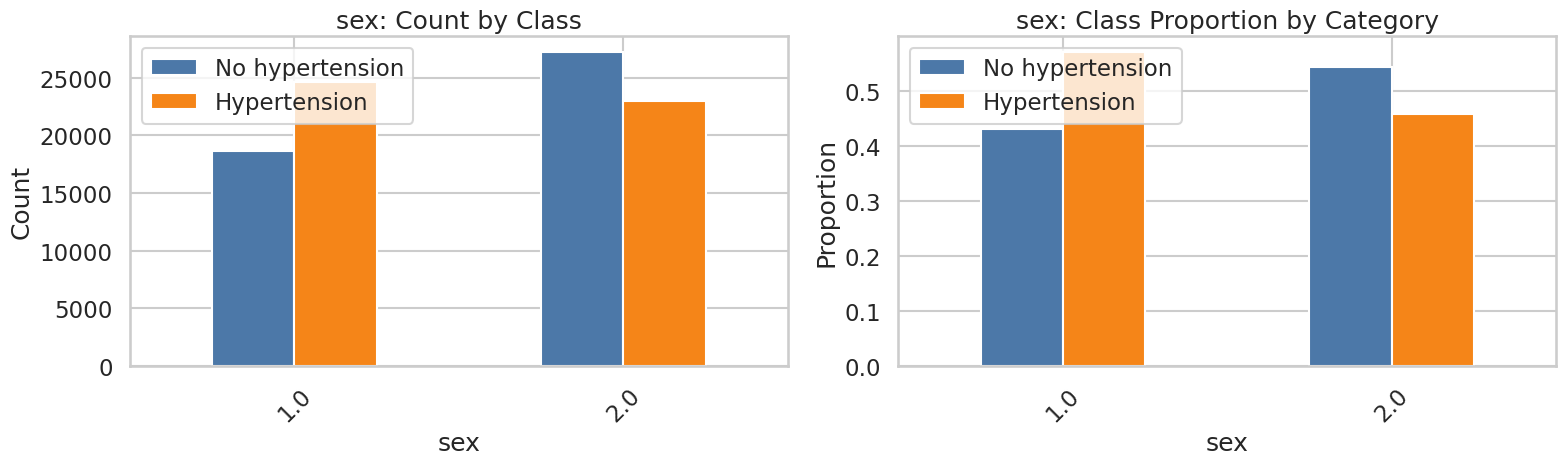

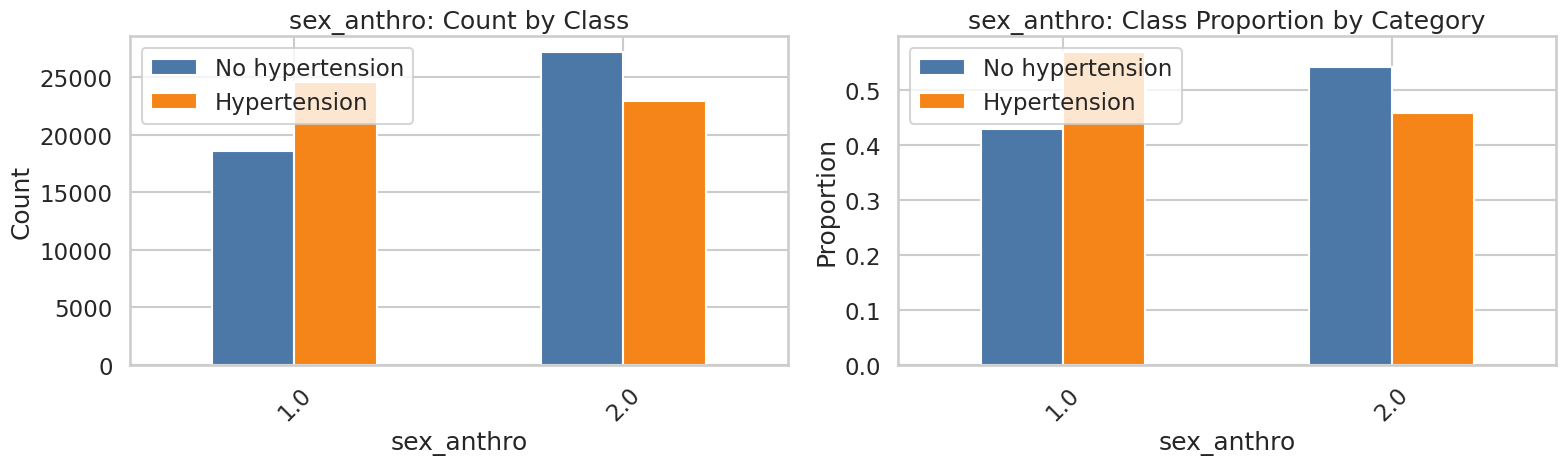

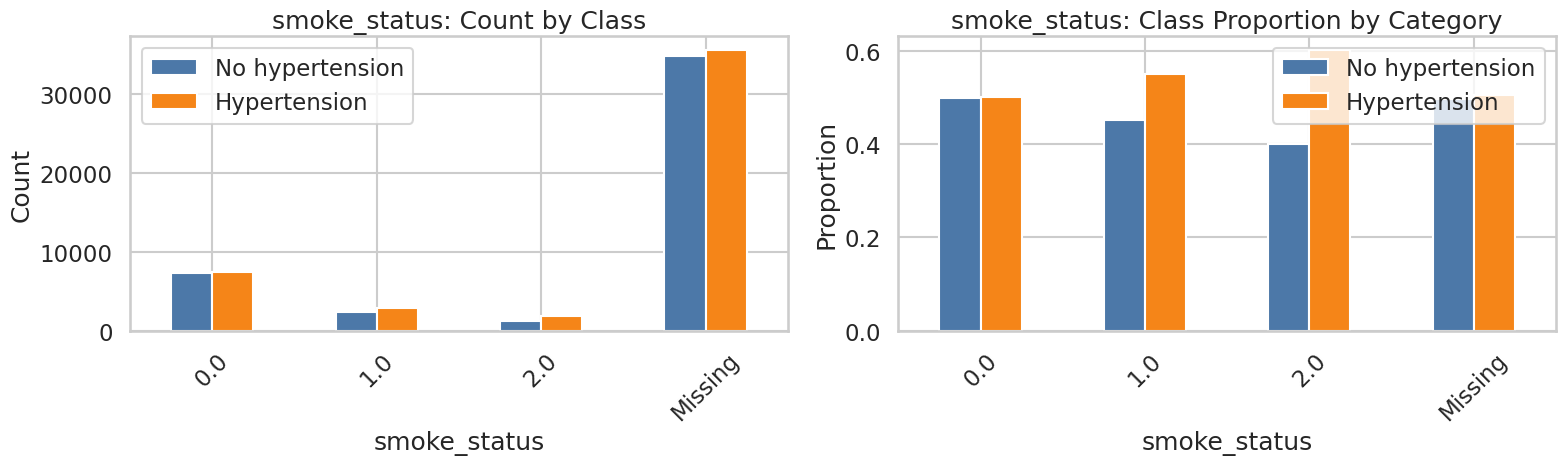

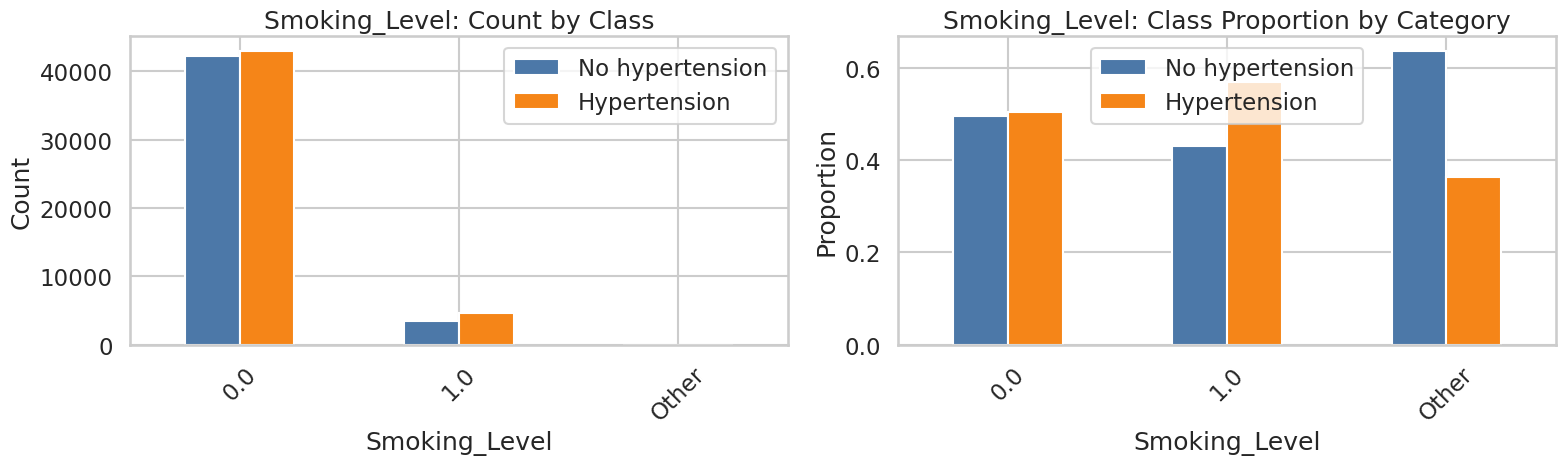

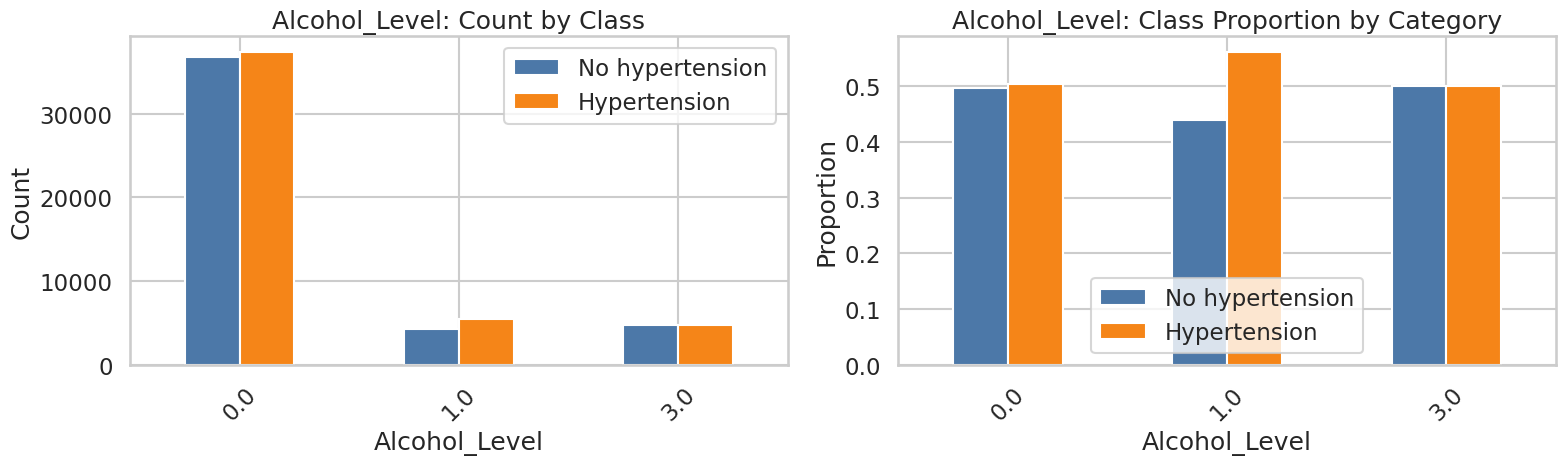

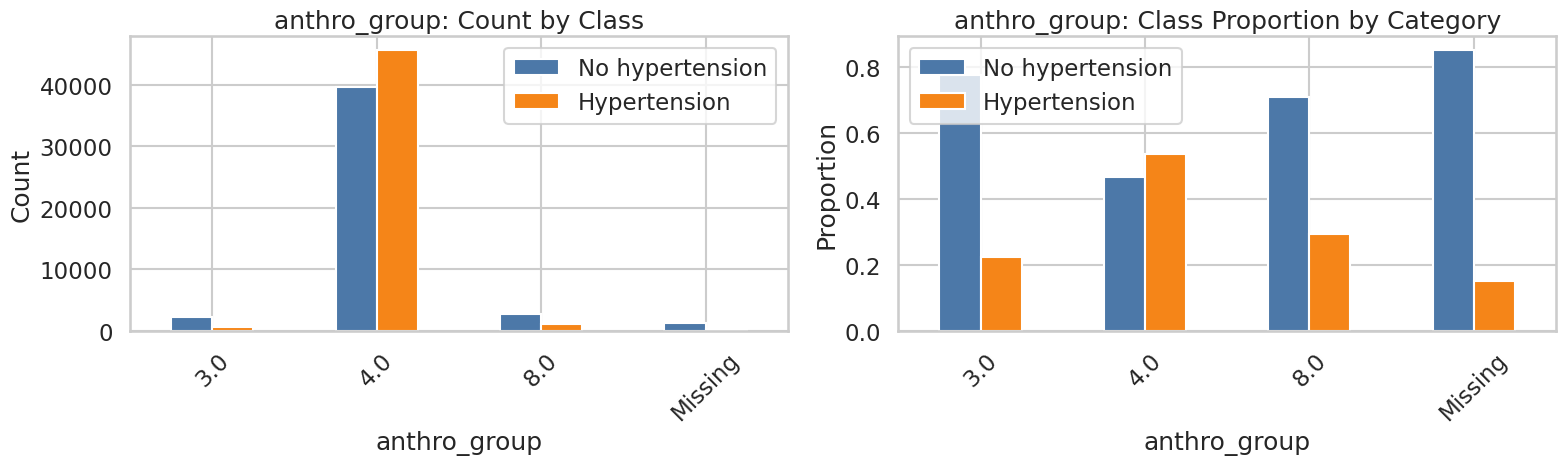

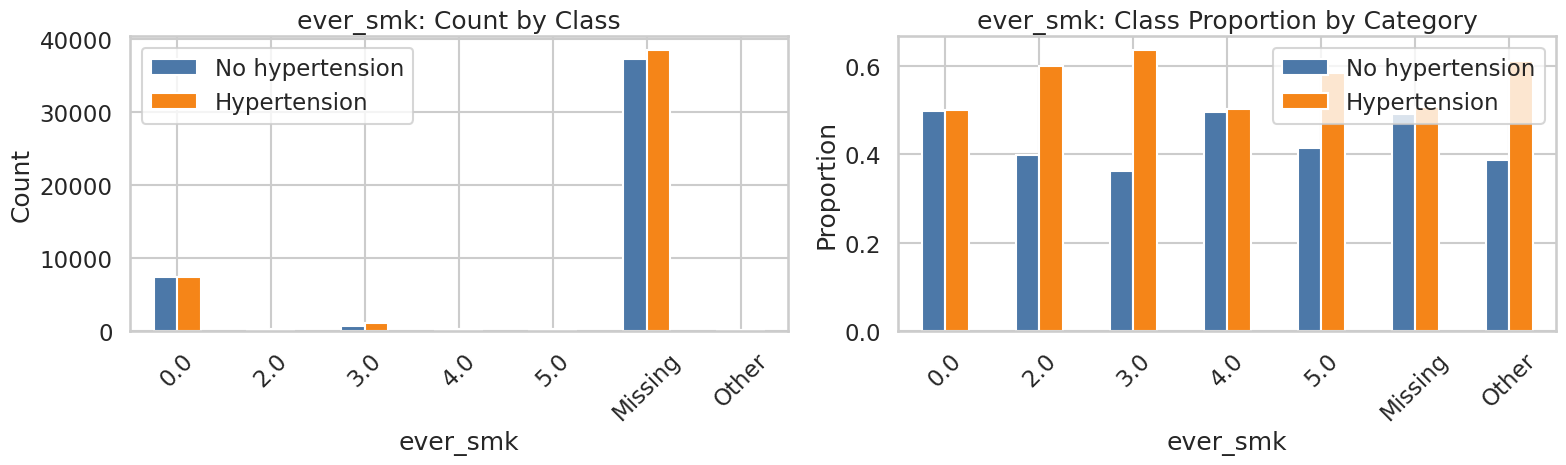

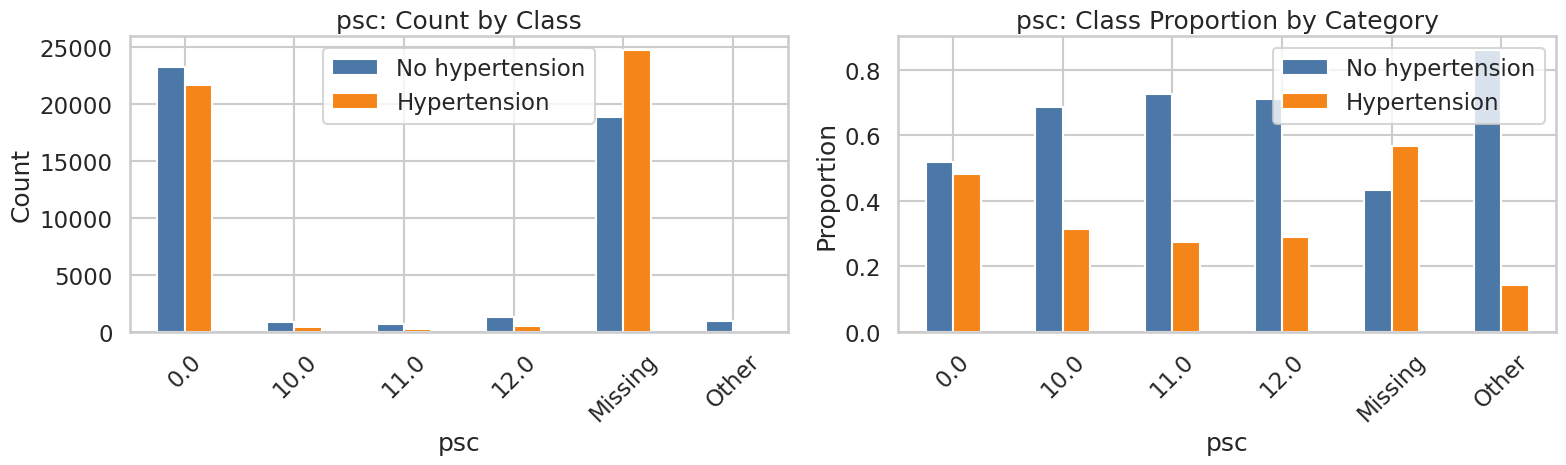

,feature,n_categories,chi2_p_value,cramers_v
5,anthro_group,4,0.000000e+00,0.167319
7,psc,6,0.000000e+00,0.146756
0,sex,2,6.590872e-255,0.111572
1,sex_anthro,2,6.590872e-255,0.111572
2,smoke_status,4,6.653483e-31,0.039191
6,ever_smk,7,7.726780e-27,0.038124
3,Smoking_Level,3,1.339573e-27,0.036395
4,Alcohol_Level,3,9.041610e-26,0.035134


,feature,missing_rate,target_corr_abs,mean,std
58,waist,0.023108,0.299607,77.634207,11.224276
71,agemos,0.000161,0.272036,521.708333,198.265250
8,age,0.000064,0.271956,43.478244,16.523507
66,age_anthro,0.000064,0.271956,43.478244,16.523507
73,WHR,0.021385,0.260919,0.877414,0.071242
57,weight,0.001274,0.257616,56.471779,11.797880
72,BMI,0.006743,0.248059,23.091873,4.199275
67,hip,0.024478,0.234218,88.259703,8.289729
63,psc_anthro,0.462661,0.124816,0.184252,0.553602
2,sex,0.000000,0.111594,1.537339,0.498607


Saved EDA figures and table to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/eda


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

eda_dir = Path.cwd() / 'gpu_only_tree_models_artifacts' / 'eda'
eda_dir.mkdir(parents=True, exist_ok=True)

eda_df = X.copy()
eda_df[target_col] = y.values

summary_rows = [
    {'metric': 'rows', 'value': len(eda_df)},
    {'metric': 'columns', 'value': len(eda_df.columns)},
    {'metric': 'numeric_features', 'value': len(numeric_features)},
    {'metric': 'categorical_features', 'value': len(categorical_features)},
    {'metric': 'target_prevalence', 'value': round(float(y.mean()), 4)},
    {'metric': 'missing_cells', 'value': int(eda_df.isna().sum().sum())},
    {'metric': 'missing_rate', 'value': round(float(eda_df.isna().sum().sum() / (eda_df.shape[0] * eda_df.shape[1])), 4)},
]
eda_summary_df = pd.DataFrame(summary_rows)
display(eda_summary_df)

# Target balance chart.
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = y.value_counts().sort_index()
target_labels = ['No hypertension', 'Hypertension']
sns.barplot(x=target_labels, y=target_counts.values, ax=ax, palette=['#4C78A8', '#F58518'])
ax.set_title('Hypertension Class Distribution (130/80 Rule)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for idx, value in enumerate(target_counts.values):
    ax.text(idx, value, f'{value:,}', ha='center', va='bottom', fontsize=11)
fig.tight_layout()
fig.savefig(eda_dir / 'target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

# Missingness bar chart for the most incomplete columns.
missing_rate = eda_df.drop(columns=[target_col]).isna().mean().sort_values(ascending=False)
top_missing = missing_rate[missing_rate > 0].head(15)
fig, ax = plt.subplots(figsize=(10, 6))
if not top_missing.empty:
    sns.barplot(x=top_missing.values, y=top_missing.index, ax=ax, color='#72B7B2')
    ax.set_title('Top Missing Features')
    ax.set_xlabel('Missing Rate')
    ax.set_ylabel('Feature')
else:
    ax.text(0.5, 0.5, 'No missing values found in features.', ha='center', va='center', fontsize=14)
    ax.axis('off')
fig.tight_layout()
fig.savefig(eda_dir / 'missingness_top_features.png', dpi=200, bbox_inches='tight')
plt.show()

# Correlation heatmap for the features most associated with the target.
corr_df = eda_df[numeric_features + [target_col]].copy()
corr_matrix = corr_df.corr(numeric_only=True)
top_target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False).head(15).index.tolist()
heatmap_cols = top_target_corr + [target_col]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix.loc[heatmap_cols, heatmap_cols], cmap='coolwarm', center=0, annot=False, ax=ax, square=True)
ax.set_title('Correlation Heatmap of Top Target-Associated Features')
fig.tight_layout()
fig.savefig(eda_dir / 'correlation_heatmap_top_features.png', dpi=200, bbox_inches='tight')
plt.show()

# Histograms for the strongest numeric predictors.
hist_features = top_target_corr[:6]
if hist_features:
    n_cols = 2
    n_rows = int(np.ceil(len(hist_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, feature in zip(axes, hist_features):
        sns.histplot(data=eda_df, x=feature, hue=target_col, kde=True, bins=30, element='step', stat='density', common_norm=False, ax=ax)
        ax.set_title(f'Distribution of {feature}')
    for ax in axes[len(hist_features):]:
        ax.axis('off')
    fig.tight_layout()
    fig.savefig(eda_dir / 'histograms_top_predictors.png', dpi=200, bbox_inches='tight')
    plt.show()

# Boxplots for paper-friendly effect visualization.
box_features = [c for c in ['age', 'BMI', 'WHR', weight_col, waist_col, hip_col] if c and c in eda_df.columns]
box_features = list(dict.fromkeys(box_features))[:6]
if box_features:
    n_cols = 2
    n_rows = int(np.ceil(len(box_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, feature in zip(axes, box_features):
        sns.boxplot(data=eda_df, x=target_col, y=feature, ax=ax, palette=['#4C78A8', '#F58518'])
        ax.set_title(f'{feature} by Hypertension Class')
        ax.set_xlabel('Hypertension')
    for ax in axes[len(box_features):]:
        ax.axis('off')
    fig.tight_layout()
    fig.savefig(eda_dir / 'boxplots_key_features.png', dpi=200, bbox_inches='tight')
    plt.show()

# Categorical-vs-target EDA: true categoricals + low-cardinality numeric categories.
cat_like_numeric = [
    c for c in numeric_features
    if c in eda_df.columns and c != target_col and eda_df[c].nunique(dropna=True) <= 8
]
priority_cats = ['sex', 'sex_anthro', 'smoke_status', 'Smoking_Level', 'Alcohol_Level', 'anthro_group']
candidate_cats = priority_cats + categorical_features + cat_like_numeric
categorical_for_eda = []
for c in candidate_cats:
    if c in eda_df.columns and c not in categorical_for_eda:
        categorical_for_eda.append(c)

categorical_for_eda = [c for c in categorical_for_eda if eda_df[c].nunique(dropna=True) > 1][:8]
cat_assoc_rows = []

for feature in categorical_for_eda:
    tmp = eda_df[[feature, target_col]].copy()
    tmp[feature] = tmp[feature].astype(str).fillna('Missing')
    tmp = tmp[tmp[feature] != 'nan']

    counts = pd.crosstab(tmp[feature], tmp[target_col])
    if counts.shape[0] < 2 or counts.shape[1] < 2:
        continue

    row_sums = counts.sum(axis=1).replace(0, np.nan)
    rates = counts.div(row_sums, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    counts.plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
    axes[0].set_title(f'{feature}: Count by Class')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(['No hypertension', 'Hypertension'])

    rates.plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
    axes[1].set_title(f'{feature}: Class Proportion by Category')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Proportion')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(['No hypertension', 'Hypertension'])

    fig.tight_layout()
    fig.savefig(eda_dir / f'categorical_target_{feature}.png', dpi=200, bbox_inches='tight')
    plt.show()

    chi2, p_value, dof, expected = chi2_contingency(counts.values)
    n = counts.values.sum()
    r, k = counts.shape
    cramer_v = np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))
    cat_assoc_rows.append({
        'feature': feature,
        'n_categories': counts.shape[0],
        'chi2_p_value': float(p_value),
        'cramers_v': float(cramer_v),
    })

if cat_assoc_rows:
    cat_assoc_df = pd.DataFrame(cat_assoc_rows).sort_values(['cramers_v', 'chi2_p_value'], ascending=[False, True])
    display(cat_assoc_df)
    cat_assoc_df.to_csv(eda_dir / 'categorical_target_associations.csv', index=False)
else:
    print('No categorical-like features available for target association charts.')

# Save a compact EDA table for the paper or appendix.
feature_summary = pd.DataFrame({
    'feature': numeric_features,
    'missing_rate': [float(eda_df[c].isna().mean()) for c in numeric_features],
    'target_corr_abs': [float(abs(corr_matrix.loc[c, target_col])) for c in numeric_features],
    'mean': [float(pd.to_numeric(eda_df[c], errors='coerce').mean()) for c in numeric_features],
    'std': [float(pd.to_numeric(eda_df[c], errors='coerce').std()) for c in numeric_features],
})
feature_summary = feature_summary.sort_values(['target_corr_abs', 'missing_rate'], ascending=[False, True])
display(feature_summary.head(20))
feature_summary.to_csv(eda_dir / 'feature_summary_for_paper.csv', index=False)

print(f'Saved EDA figures and table to: {eda_dir}')

In [ ]:
# 70/15/15 nested stratified split.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

split_summary = {
    'n_total': len(X),
    'n_train': len(X_train),
    'n_val': len(X_val),
    'n_test': len(X_test),
    'train_ratio': round(len(X_train) / len(X), 4),
    'val_ratio': round(len(X_val) / len(X), 4),
    'test_ratio': round(len(X_test) / len(X), 4),
}
print('Split summary:', split_summary)

num_cols = [c for c in numeric_features if c in X_train.columns]
cat_cols = [c for c in categorical_features if c in X_train.columns]

X_train_num = X_train[num_cols].apply(pd.to_numeric, errors='coerce')
X_val_num = X_val[num_cols].apply(pd.to_numeric, errors='coerce')
X_test_num = X_test[num_cols].apply(pd.to_numeric, errors='coerce')

# Pre-imputation scaling (fit on train only).
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=num_cols,
    index=X_train.index
)
X_val_num_scaled = pd.DataFrame(
    scaler.transform(X_val_num),
    columns=num_cols,
    index=X_val.index
)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=num_cols,
    index=X_test.index
)

# K selection by artificial masking on a sampled subset of train numerics.
# This keeps the masking benchmark tractable while still choosing K from train data.
rng = np.random.default_rng(42)
sample_size = min(3000, len(X_train_num_scaled))
sample_idx = rng.choice(len(X_train_num_scaled), size=sample_size, replace=False)
k_selection_frame = X_train_num_scaled.iloc[sample_idx].copy()
observed_positions = np.argwhere(~np.isnan(k_selection_frame.values))
if len(observed_positions) == 0:
    raise ValueError('No observed numeric values available for KNN masking experiment.')

mask_count = min(500, len(observed_positions))
mask_idx = observed_positions[rng.choice(len(observed_positions), size=mask_count, replace=False)]
masked = k_selection_frame.values.copy()
truth = np.array([masked[i, j] for i, j in mask_idx])
for i, j in mask_idx:
    masked[i, j] = np.nan

k_grid = [3, 5, 7]
k_scores = []
for k in k_grid:
    imp = KNNImputer(n_neighbors=k, weights='distance')
    rec = imp.fit_transform(masked)
    pred = np.array([rec[i, j] for i, j in mask_idx])
    mae = float(np.mean(np.abs(pred - truth)))
    k_scores.append({'k': k, 'mae': mae})

best_k = min(k_scores, key=lambda d: d['mae'])['k']
print('KNN masking sample size:', sample_size)
print('KNN masking scores:', k_scores)
print('Selected K for KNN imputation:', best_k)

knn_imputer = KNNImputer(n_neighbors=best_k, weights='distance')
X_train_num_imp = pd.DataFrame(
    knn_imputer.fit_transform(X_train_num_scaled),
    columns=num_cols,
    index=X_train.index
)
X_val_num_imp = pd.DataFrame(
    knn_imputer.transform(X_val_num_scaled),
    columns=num_cols,
    index=X_val.index
)
X_test_num_imp = pd.DataFrame(
    knn_imputer.transform(X_test_num_scaled),
    columns=num_cols,
    index=X_test.index
)

# Strict collinearity filtering on train numerics: drop one feature for |r| > 0.70.
corr = X_train_num_imp.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr_cols = [col for col in upper.columns if any(upper[col] > 0.70)]
keep_num_cols = [c for c in X_train_num_imp.columns if c not in drop_corr_cols]

X_train_num_final = X_train_num_imp[keep_num_cols]
X_val_num_final = X_val_num_imp[keep_num_cols]
X_test_num_final = X_test_num_imp[keep_num_cols]
print(f'Numeric features before/after collinearity filter: {len(num_cols)} -> {len(keep_num_cols)}')

# Categorical imputation (mode) and one-hot encoding.
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), columns=cat_cols, index=X_train.index).astype(str) if cat_cols else pd.DataFrame(index=X_train.index)
X_val_cat = pd.DataFrame(cat_imputer.transform(X_val[cat_cols]), columns=cat_cols, index=X_val.index).astype(str) if cat_cols else pd.DataFrame(index=X_val.index)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=cat_cols, index=X_test.index).astype(str) if cat_cols else pd.DataFrame(index=X_test.index)

if cat_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    X_train_cat_ohe = ohe.fit_transform(X_train_cat)
    X_val_cat_ohe = ohe.transform(X_val_cat)
    X_test_cat_ohe = ohe.transform(X_test_cat)
else:
    X_train_cat_ohe = sparse.csr_matrix((len(X_train), 0))
    X_val_cat_ohe = sparse.csr_matrix((len(X_val), 0))
    X_test_cat_ohe = sparse.csr_matrix((len(X_test), 0))

X_train_proc = hstack([sparse.csr_matrix(X_train_num_final.values), X_train_cat_ohe], format='csr')
X_val_proc = hstack([sparse.csr_matrix(X_val_num_final.values), X_val_cat_ohe], format='csr')
X_test_proc = hstack([sparse.csr_matrix(X_test_num_final.values), X_test_cat_ohe], format='csr')

print('Train matrix shape:', X_train_proc.shape)
print('Val matrix shape:', X_val_proc.shape)
print('Test matrix shape:', X_test_proc.shape)

# Preprocessing sanity checks: no leakage, consistent columns, and no NaNs after encoding.
assert X_train_num_final.columns.tolist() == X_val_num_final.columns.tolist() == X_test_num_final.columns.tolist(), 'Numeric columns are not aligned across splits.'
expected_feature_count = X_train_proc.shape[1]
assert X_val_proc.shape[1] == expected_feature_count == X_test_proc.shape[1], 'Encoded feature counts do not match across splits.'
preprocessing_checks = {
    'train_numeric_missing': int(X_train_num_final.isna().sum().sum()),
    'val_numeric_missing': int(X_val_num_final.isna().sum().sum()),
    'test_numeric_missing': int(X_test_num_final.isna().sum().sum()),
    'train_categorical_missing': int(X_train_cat.isna().sum().sum()) if cat_cols else 0,
    'val_categorical_missing': int(X_val_cat.isna().sum().sum()) if cat_cols else 0,
    'test_categorical_missing': int(X_test_cat.isna().sum().sum()) if cat_cols else 0,
    'feature_count': int(expected_feature_count),
    'numeric_features_kept': int(len(keep_num_cols)),
    'categorical_features_encoded': int(len(ohe.get_feature_names_out(cat_cols))) if cat_cols else 0,
}
print('Preprocessing checks:', preprocessing_checks)
assert preprocessing_checks['train_numeric_missing'] == 0, 'Unexpected NaNs in train numeric block after imputation.'
assert preprocessing_checks['val_numeric_missing'] == 0, 'Unexpected NaNs in validation numeric block after imputation.'
assert preprocessing_checks['test_numeric_missing'] == 0, 'Unexpected NaNs in test numeric block after imputation.'
assert preprocessing_checks['train_categorical_missing'] == 0, 'Unexpected NaNs in train categorical block after imputation.'
assert preprocessing_checks['val_categorical_missing'] == 0, 'Unexpected NaNs in validation categorical block after imputation.'
assert preprocessing_checks['test_categorical_missing'] == 0, 'Unexpected NaNs in test categorical block after imputation.'

Split summary: {'n_total': 93429, 'n_train': 65400, 'n_val': 14014, 'n_test': 14015, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15}


KNN masking sample size: 3000
KNN masking scores: [{'k': 3, 'mae': 0.3384571789680465}, {'k': 5, 'mae': 0.32503288042000783}, {'k': 7, 'mae': 0.3260704702287103}]
Selected K for KNN imputation: 5
Numeric features before/after collinearity filter: 75 -> 41
Train matrix shape: (65400, 64)
Val matrix shape: (14014, 64)
Test matrix shape: (14015, 64)
Preprocessing checks: {'train_numeric_missing': 0, 'val_numeric_missing': 0, 'test_numeric_missing': 0, 'train_categorical_missing': 0, 'val_categorical_missing': 0, 'test_categorical_missing': 0, 'feature_count': 64, 'numeric_features_kept': 41, 'categorical_features_encoded': 23}


In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).clip(1e-7, 1 - 1e-7)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            in_bin = (y_prob >= lo) & (y_prob < hi)
        else:
            in_bin = (y_prob >= lo) & (y_prob <= hi)
        if np.any(in_bin):
            acc = y_true[in_bin].mean()
            conf = y_prob[in_bin].mean()
            ece += np.abs(acc - conf) * (np.sum(in_bin) / len(y_prob))
    return float(ece)


def dense_matrix(matrix):
    return matrix.toarray().astype(np.float32, copy=False) if sparse.issparse(matrix) else np.asarray(matrix, dtype=np.float32)


def positive_class_weight(y_labels):
    y_arr = np.asarray(y_labels).astype(int)
    counts = np.bincount(y_arr)
    if len(counts) < 2 or counts[1] == 0:
        return 1.0
    return float(counts[0] / counts[1])


EPOCHS = globals().get('EPOCHS', 500)
N_JOBS = globals().get('N_JOBS', -1)

LIGHTGBM_GPU_ENABLED = True


def build_model(model_family, use_class_weight, pos_weight, tuned_params=None):
    tuned_params = tuned_params or {}

    if model_family == 'RandomForest_GPU_XGBRF':
        params = {
            'n_estimators': EPOCHS,
            'max_depth': 10,
            'learning_rate': 1.0,
            'subsample': 0.85,
            'colsample_bynode': 0.85,
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'tree_method': 'hist',
            'device': 'cuda',
            'random_state': 42,
            'n_jobs': N_JOBS,
        }
        params.update(tuned_params)
        if use_class_weight:
            params['scale_pos_weight'] = pos_weight
        return XGBRFClassifier(**params)

    if model_family == 'XGBoost_GPU':
        params = {
            'n_estimators': EPOCHS,
            'max_depth': 8,
            'learning_rate': 0.05,
            'subsample': 0.85,
            'colsample_bytree': 0.85,
            'min_child_weight': 1,
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'tree_method': 'hist',
            'device': 'cuda',
            'random_state': 42,
            'n_jobs': N_JOBS,
        }
        params.update(tuned_params)
        if use_class_weight:
            params['scale_pos_weight'] = pos_weight
        return XGBClassifier(**params)

    if model_family == 'CatBoost_GPU':
        params = {
            'iterations': EPOCHS,
            'depth': 8,
            'learning_rate': 0.05,
            'l2_leaf_reg': 3.0,
            'loss_function': 'Logloss',
            'eval_metric': 'accuracy',
            'task_type': 'GPU',
            'devices': '0',
            'random_seed': 42,
            'thread_count': N_JOBS,
            'verbose': False,
        }
        params.update(tuned_params)
        if use_class_weight:
            params['class_weights'] = [1.0, pos_weight]
        return CatBoostClassifier(**params)

    if model_family == 'LightGBM_GPU':
        device_choice = 'gpu' if LIGHTGBM_GPU_ENABLED else 'cpu'
        params = {
            'n_estimators': EPOCHS,
            'learning_rate': 0.05,
            'num_leaves': 63,
            'min_child_samples': 20,
            'subsample': 0.85,
            'colsample_bytree': 0.85,
            'objective': 'binary',
            'device_type': device_choice,
            'verbosity': -1,
            'force_col_wise': True,
            'feature_pre_filter': False,
            'random_state': 42,
            'n_jobs': N_JOBS,
        }
        params.update(tuned_params)
        if use_class_weight:
            params['class_weight'] = {0: 1.0, 1: pos_weight}
        return LGBMClassifier(**params)

    raise ValueError(f'Unknown model family: {model_family}')


def sanitize_probabilities(probabilities):
    sanitized = np.asarray(probabilities, dtype=float).reshape(-1)
    sanitized = np.nan_to_num(sanitized, nan=0.5, posinf=1.0, neginf=0.0)
    return np.clip(sanitized, 1e-7, 1 - 1e-7)


def fit_estimator(model_family, estimator, X_fit, y_fit):
    if model_family != 'LightGBM_GPU':
        estimator.fit(X_fit, y_fit)
        return estimator, 'gpu'

    global LIGHTGBM_GPU_ENABLED

    if not LIGHTGBM_GPU_ENABLED:
        cpu_params = estimator.get_params()
        cpu_params['device_type'] = 'cpu'
        cpu_params['verbosity'] = -1
        cpu_params['force_col_wise'] = True
        cpu_params['feature_pre_filter'] = False
        cpu_estimator = LGBMClassifier(**cpu_params)
        cpu_estimator.fit(X_fit, y_fit)
        return cpu_estimator, 'cpu'

    try:
        estimator.fit(X_fit, y_fit)
        return estimator, 'gpu'
    except Exception as gpu_error:
        LIGHTGBM_GPU_ENABLED = False
        print(f'LightGBM GPU unavailable in this runtime; switching to CPU for all remaining LightGBM trials: {type(gpu_error).__name__}: {gpu_error}')
        fallback_params = estimator.get_params()
        fallback_params['device_type'] = 'cpu'
        fallback_params['verbosity'] = -1
        fallback_params['force_col_wise'] = True
        fallback_params['feature_pre_filter'] = False
        fallback_estimator = LGBMClassifier(**fallback_params)
        fallback_estimator.fit(X_fit, y_fit)
        return fallback_estimator, 'cpu'


def get_search_space(model_family):
    if model_family == 'RandomForest_GPU_XGBRF':
        return {
            'n_estimators': [300, 500, 700, 900, 1200],
            'max_depth': [6, 8, 10, 12, 14],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
            'colsample_bynode': [0.6, 0.7, 0.8, 0.9, 1.0],
            'min_child_weight': [1, 2, 3, 5, 7],
            'gamma': [0.0, 0.25, 0.5, 1.0, 2.0],
            'reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0, 2.0],
            'reg_lambda': [0.5, 1.0, 2.0, 3.0, 5.0, 8.0],
        }

    if model_family == 'XGBoost_GPU':
        return {
            'n_estimators': [300, 500, 700, 900, 1200],
            'max_depth': [4, 6, 8, 10, 12],
            'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
            'min_child_weight': [1, 2, 3, 5, 7],
            'gamma': [0.0, 0.25, 0.5, 1.0, 2.0],
            'reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0, 2.0],
            'reg_lambda': [0.5, 1.0, 2.0, 3.0, 5.0, 8.0],
            'max_delta_step': [0, 1, 2, 3, 5],
            'colsample_bylevel': [0.6, 0.7, 0.8, 0.9, 1.0],
            'max_bin': [256, 384, 512, 768],
        }

    if model_family == 'CatBoost_GPU':
        return {
            'iterations': [300, 500, 700, 900, 1200],
            'depth': [4, 6, 8, 10],
            'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
            'l2_leaf_reg': [1.0, 2.0, 3.0, 5.0, 7.0, 10.0],
            'bagging_temperature': [0.0, 0.25, 0.5, 1.0, 2.0],
            'random_strength': [0.0, 0.5, 1.0, 2.0, 4.0],
            'border_count': [64, 128, 254],
            'min_data_in_leaf': [1, 5, 10, 20, 40],
        }

    if model_family == 'LightGBM_GPU':
        return {
            'n_estimators': [300, 500, 700, 900, 1200],
            'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
            'num_leaves': [31, 63, 95, 127, 191, 255],
            'min_child_samples': [10, 20, 30, 40, 60, 80],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
            'reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0, 2.0],
            'reg_lambda': [0.5, 1.0, 2.0, 3.0, 5.0, 8.0],
            'min_split_gain': [0.0, 0.05, 0.1, 0.25, 0.5, 1.0],
            'max_bin': [127, 255, 383, 511],
        }

    raise ValueError(f'Unknown model family: {model_family}')


def apply_balance_method(X_fit, y_fit, balance_method):
    if balance_method in {'base', 'classweights'}:
        return X_fit, y_fit

    if balance_method in {'adasyn', 'adasyn_cw'}:
        sampler = ADASYN(random_state=42, n_neighbors=5)
        try:
            return sampler.fit_resample(X_fit, y_fit)
        except ValueError as e:
            if 'No samples will be generated' in str(e):
                print(f'ADASYN skipped for this split (already near-balanced): {e}')
                return X_fit, y_fit
            raise

    if balance_method in {'smote', 'smote_cw'}:
        sampler = SMOTE(random_state=42, k_neighbors=5)
        try:
            return sampler.fit_resample(X_fit, y_fit)
        except ValueError as e:
            if 'No samples will be generated' in str(e):
                print(f'SMOTE skipped for this split (already near-balanced): {e}')
                return X_fit, y_fit
            raise

    raise ValueError(f'Unknown balance method: {balance_method}')


def fit_calibrators(y_fit, p_fit):
    calibrators = {}

    platt = LogisticRegression(solver='lbfgs', max_iter=1000)
    platt.fit(p_fit.reshape(-1, 1), y_fit)
    calibrators['platt'] = lambda p, model=platt: model.predict_proba(np.asarray(p).reshape(-1, 1))[:, 1]

    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_fit, y_fit)
    calibrators['isotonic'] = lambda p, model=iso: np.clip(model.predict(np.asarray(p).reshape(-1)), 1e-7, 1 - 1e-7)

    try:
        from venn_abers import VennAbers

        p_fit_vec = np.asarray(p_fit, dtype=float).reshape(-1)
        p_fit_2col = np.column_stack([1.0 - p_fit_vec, p_fit_vec])
        venn = VennAbers()
        venn.fit(p_fit_2col, y_fit)

        def venn_predict(p, model=venn):
            p_vec = np.asarray(p, dtype=float).reshape(-1)
            p_2col = np.column_stack([1.0 - p_vec, p_vec])
            raw = np.asarray(model.predict_proba(p_2col))

            if raw.ndim == 3 and raw.shape[0] == 2 and raw.shape[2] == 2:
                p_lo = raw[0, :, 1]
                p_hi = raw[1, :, 1]
                return np.clip(0.5 * (p_lo + p_hi), 1e-7, 1 - 1e-7)

            if raw.ndim == 2 and raw.shape[1] == 2:
                return np.clip(raw[:, 1], 1e-7, 1 - 1e-7)

            if raw.ndim == 2 and raw.shape[0] == 2:
                return np.clip(raw[1, :], 1e-7, 1 - 1e-7)

            return np.clip(raw.reshape(-1), 1e-7, 1 - 1e-7)

        calibrators['venn_abers'] = venn_predict
    except Exception as e:
        print(f'Venn-Abers unavailable for calibration: {type(e).__name__}: {e}')

    return calibrators


def choose_operating_threshold(
    y_true,
    y_prob,
    threshold_grid=None,
    recall_weight=0.65,
    accuracy_weight=0.35,
    min_recall=None,
    min_accuracy=None,
):
    if threshold_grid is None:
        threshold_grid = np.linspace(0.01, 0.99, 197)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    best = None
    eligible = []
    for threshold in threshold_grid:
        y_pred = (y_prob >= threshold).astype(int)
        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        score = float(recall_weight * max(rec, 0.0) + accuracy_weight * max(acc, 0.0))
        candidate = {
            'threshold': float(threshold),
            'accuracy': float(acc),
            'recall': float(rec),
            'score': score,
        }

        passes_floor = True
        if min_recall is not None and candidate['recall'] < float(min_recall):
            passes_floor = False
        if min_accuracy is not None and candidate['accuracy'] < float(min_accuracy):
            passes_floor = False
        if passes_floor:
            eligible.append(candidate)

        if best is None or candidate['score'] > best['score'] or (candidate['score'] == best['score'] and candidate['recall'] > best['recall']):
            best = candidate

    if eligible:
        eligible = sorted(eligible, key=lambda d: (d['score'], d['recall'], d['accuracy']), reverse=True)
        return eligible[0]

    return best


balance_methods = ['base', 'adasyn', 'smote', 'classweights', 'adasyn_cw', 'smote_cw']
model_families = ['RandomForest_GPU_XGBRF', 'XGBoost_GPU', 'CatBoost_GPU', 'LightGBM_GPU']

X_train_dense = dense_matrix(X_train_proc)
X_val_dense = dense_matrix(X_val_proc)
X_test_dense = dense_matrix(X_test_proc)
pos_weight = positive_class_weight(y_train)

# More exhaustive GPU search budget per (model x balance) configuration.
optimization_n_iter = 120

all_results = []
fitted_models = {}

for balance_method in balance_methods:
    X_fit, y_fit = apply_balance_method(X_train_dense, y_train.values, balance_method)
    use_class_weight = balance_method in {'classweights', 'adasyn_cw', 'smote_cw'}

    print(f'\n=== Balance method: {balance_method} | train size after balance: {len(y_fit)} ===')

    for model_family in model_families:
        config_name = f'{model_family}__{balance_method}'
        search_space = get_search_space(model_family)
        sampled_params = list(ParameterSampler(search_space, n_iter=optimization_n_iter, random_state=42))
        t0 = time.time()

        best_trial = None
        best_model = None

        for trial_idx, trial_params in enumerate(sampled_params, start=1):
            try:
                trial_model = build_model(model_family, use_class_weight, pos_weight, tuned_params=trial_params)
                trial_model, trial_device = fit_estimator(model_family, trial_model, X_fit, y_fit)
                trial_prob = sanitize_probabilities(trial_model.predict_proba(X_val_dense)[:, 1])
                trial_pred = (trial_prob >= 0.5).astype(int)
                trial_score = {
                    'trial': trial_idx,
                    'params': trial_params,
                    'device': trial_device,
                    'val_accuracy': float(accuracy_score(y_val, trial_pred)),
                    'val_recall': float(recall_score(y_val, trial_pred, zero_division=0)),
                }
                if (
                    best_trial is None
                    or trial_score['val_recall'] > best_trial['val_recall']
                    or (trial_score['val_recall'] == best_trial['val_recall'] and trial_score['val_accuracy'] > best_trial['val_accuracy'])
                ):
                    best_trial = trial_score
                    best_model = trial_model
            except Exception as e:
                print(f"Optimization trial failed for {config_name}, trial={trial_idx}: {type(e).__name__}: {e}")

        if best_model is None:
            row = {
                'config_name': config_name,
                'model_family': model_family,
                'balance_method': balance_method,
                'use_class_weight': use_class_weight,
                'train_samples': int(len(y_fit)),
                'status': 'failed',
                'train_seconds': round(time.time() - t0, 2),
                'error': 'All optimization trials failed',
            }
            all_results.append(row)
            print('Failed:', row)
            continue

        y_prob_val = sanitize_probabilities(best_model.predict_proba(X_val_dense)[:, 1])
        y_pred_val = (y_prob_val >= 0.5).astype(int)

        row = {
            'config_name': config_name,
            'model_family': model_family,
            'balance_method': balance_method,
            'use_class_weight': use_class_weight,
            'train_samples': int(len(y_fit)),
            'status': 'ok',
            'train_seconds': round(time.time() - t0, 2),
            'optimization_trials': len(sampled_params),
            'best_trial_idx': best_trial['trial'],
            'best_params': str(best_trial['params']),
            'val_accuracy': accuracy_score(y_val, y_pred_val),
            'val_recall': recall_score(y_val, y_pred_val, zero_division=0),
            'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
            'val_f1': f1_score(y_val, y_pred_val, zero_division=0),
            'val_log_loss': log_loss(y_val, y_prob_val),
            'val_ece': expected_calibration_error(y_val.values, y_prob_val),
            'val_device': best_trial['device'],
        }

        fitted_models[config_name] = {
            'estimator': best_model,
            'model_family': model_family,
            'balance_method': balance_method,
            'use_class_weight': use_class_weight,
            'best_params': best_trial['params'],
        }
        all_results.append(row)
        print('Done:', {k: row[k] for k in ['config_name', 'val_accuracy', 'val_recall', 'val_ece', 'best_trial_idx', 'val_device']})

results_df = pd.DataFrame(all_results)
ok_df = results_df[results_df['status'] == 'ok'].copy()
if ok_df.empty:
    raise RuntimeError('No configuration trained successfully.')

# Stage 1: within each balance method, keep the top 2 by recall and accuracy.
stage1_frames = []
for balance_method, group in ok_df.groupby('balance_method', sort=False):
    ranked = group.sort_values(
        ['val_recall', 'val_accuracy', 'val_f1', 'val_precision', 'val_ece'],
        ascending=[False, False, False, False, True],
    ).head(2)
    stage1_frames.append(ranked)

stage1_df = pd.concat(stage1_frames, ignore_index=True)

# Stage 2: from those, keep the top 2 per model family by recall and accuracy.
stage2_frames = []
for model_family, group in stage1_df.groupby('model_family', sort=False):
    ranked = group.sort_values(
        ['val_recall', 'val_accuracy', 'val_f1', 'val_precision', 'val_ece'],
        ascending=[False, False, False, False, True],
    ).head(2)
    stage2_frames.append(ranked)

selected_df = pd.concat(stage2_frames, ignore_index=True)
selected_df = selected_df.sort_values(
    ['model_family', 'balance_method', 'val_accuracy', 'val_recall'],
    ascending=[True, True, False, False],
)

print('\nAll trained configurations:', len(results_df))
print('Stage 1 shortlisted configurations:', len(stage1_df))
print('Stage 2 recorded configurations:', len(selected_df))
print(selected_df[['config_name', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_ece', 'val_log_loss', 'best_params']])

# Calibration uses only the validation split, subdivided into fit/eval.
X_cal_fit, X_cal_eval, y_cal_fit, y_cal_eval = train_test_split(
    X_val_dense, y_val.values, test_size=0.5, random_state=42, stratify=y_val
)

calibration_rows = []
final_rows = []

for _, row in selected_df.iterrows():
    config_name = row['config_name']
    model_bundle = fitted_models[config_name]
    model = model_bundle['estimator']

    p_fit = sanitize_probabilities(model.predict_proba(X_cal_fit)[:, 1])
    p_eval = sanitize_probabilities(model.predict_proba(X_cal_eval)[:, 1])
    p_test = sanitize_probabilities(model.predict_proba(X_test_dense)[:, 1])

    calibrators = fit_calibrators(y_cal_fit, p_fit)
    calibrators['identity'] = lambda p: sanitize_probabilities(np.asarray(p).reshape(-1))
    candidate_rows = []

    for cal_name, predictor in calibrators.items():
        p_eval_cal = sanitize_probabilities(np.asarray(predictor(p_eval)).reshape(-1))
        operating = choose_operating_threshold(
            y_cal_eval,
            p_eval_cal,
            recall_weight=0.80,
            accuracy_weight=0.20,
            min_recall=0.75,
        )
        candidate_rows.append({
            'config_name': config_name,
            'model_family': model_bundle['model_family'],
            'balance_method': model_bundle['balance_method'],
            'best_params': str(model_bundle['best_params']),
            'calibration_method': cal_name,
            'val_ece': expected_calibration_error(y_cal_eval, p_eval_cal),
            'val_log_loss': log_loss(y_cal_eval, p_eval_cal),
            'operating_threshold': operating['threshold'],
            'operating_score': operating['score'],
            'operating_val_accuracy': operating['accuracy'],
            'operating_val_recall': operating['recall'],
        })

    candidate_df = pd.DataFrame(candidate_rows).sort_values(
        ['operating_score', 'operating_val_recall', 'operating_val_accuracy', 'val_ece', 'val_log_loss'],
        ascending=[False, False, False, True, True],
    )
    calibration_rows.extend(candidate_rows)
    best_calibration = candidate_df.iloc[0]
    best_cal_name = best_calibration['calibration_method']
    best_predictor = calibrators[best_cal_name]

    p_test_cal = sanitize_probabilities(np.asarray(best_predictor(p_test)).reshape(-1))
    best_threshold = {
        'threshold': float(best_calibration['operating_threshold']),
        'score': float(best_calibration['operating_score']),
        'accuracy': float(best_calibration['operating_val_accuracy']),
        'recall': float(best_calibration['operating_val_recall']),
    }
    y_test_pred = (p_test_cal >= best_threshold['threshold']).astype(int)

    final_rows.append({
        'config_name': config_name,
        'model_family': model_bundle['model_family'],
        'balance_method': model_bundle['balance_method'],
        'best_params': str(model_bundle['best_params']),
        'selected_calibration': best_cal_name,
        'operating_threshold': best_threshold['threshold'],
        'operating_score': best_threshold['score'],
        'operating_val_accuracy': best_threshold['accuracy'],
        'operating_val_recall': best_threshold['recall'],
        'val_ece': float(best_calibration['val_ece']),
        'val_log_loss': float(best_calibration['val_log_loss']),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'test_log_loss': log_loss(y_test, p_test_cal),
        'test_ece': expected_calibration_error(y_test.values, p_test_cal),
    })

calibration_df = pd.DataFrame(calibration_rows).sort_values(
    ['config_name', 'val_ece', 'val_log_loss'],
    ascending=[True, True, True],
)
final_selected_df = pd.DataFrame(final_rows).sort_values(
    ['test_recall', 'test_accuracy', 'operating_score'],
    ascending=[False, False, False],
)

best_overall_row = final_selected_df.iloc[0].to_dict()
final_test_metrics = best_overall_row

print('\nCalibration leaderboard (all 3 calibrators for the 8 recorded models):')
print(calibration_df)
print('\nFinal calibrated results for the 8 recorded models:')
print(final_selected_df)
print('\nBest overall calibrated model:')
print(best_overall_row)

results_df


=== Balance method: base | train size after balance: 65400 ===


In [ ]:
artifact_dir = Path.cwd() / 'gpu_only_tree_models_artifacts'
artifact_dir.mkdir(parents=True, exist_ok=True)

results_path = artifact_dir / 'gpu_only_model_results.csv'
results_df.to_csv(results_path, index=False)

stage1_path = artifact_dir / 'stage1_shortlist.csv'
if 'stage1_df' in globals():
    stage1_df.to_csv(stage1_path, index=False)

selected_path = artifact_dir / 'stage2_recorded_models.csv'
if 'selected_df' in globals():
    selected_df.to_csv(selected_path, index=False)

calibration_path = artifact_dir / 'calibration_leaderboard.csv'
if 'calibration_df' in globals():
    calibration_df.to_csv(calibration_path, index=False)

summary_path = artifact_dir / 'final_calibrated_test_metrics.csv'
if 'final_selected_df' in globals():
    final_selected_df.to_csv(summary_path, index=False)

print(f'Saved model results to: {results_path}')
if 'stage1_df' in globals():
    print(f'Saved stage 1 shortlist to: {stage1_path}')
if 'selected_df' in globals():
    print(f'Saved stage 2 recorded models to: {selected_path}')
if 'calibration_df' in globals():
    print(f'Saved calibration leaderboard to: {calibration_path}')
if 'final_selected_df' in globals():
    print(f'Saved final calibrated results to: {summary_path}')

ok_models = results_df[results_df['status'] == 'ok']['config_name'].tolist()
failed_models = results_df[results_df['status'] == 'failed']['config_name'].tolist()

print('Successful configurations:', ok_models)
print('Failed configurations:', failed_models)

if failed_models:
    print('\nAt least one configuration failed. Check the errors above for sampler/model compatibility issues.')

Saved model results to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/gpu_only_model_results.csv
Saved stage 1 shortlist to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/stage1_shortlist.csv
Saved stage 2 recorded models to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/stage2_recorded_models.csv
Saved calibration leaderboard to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/calibration_leaderboard.csv
Saved final calibrated results to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/final_calibrated_test_metrics.csv
Successful configurations: ['RandomForest_GPU_XGBRF__base', 'XGBoost_GPU__base', 'CatBoost_GPU__base', 'LightGBM_GPU__base', 'RandomForest_GPU_XGBRF__adasyn', 'XGBoost_GPU__adasyn', 'CatBoost_GPU__adasyn', 'LightGBM_GPU__adasyn', 'RandomForest_GPU_XGBRF__smote', 'XGBoost_GPU__smote', 'CatBoost_GPU__smote', 'LightGBM_GPU__smote', 'RandomForest_GPU_XGBRF__classweights', 'XGBoost_GPU__classweights', 'CatBoos

In [ ]:

# Accuracy-led optimization pass on the same cleaned data.
# This reruns the GPU sweep but changes trial selection and ranking to favor accuracy first.
accuracy_optimization_n_iter = 120
accuracy_all_results = []
accuracy_fitted_models = {}

for balance_method in balance_methods:
    X_fit, y_fit = apply_balance_method(X_train_dense, y_train.values, balance_method)
    use_class_weight = balance_method in {'classweights', 'adasyn_cw', 'smote_cw'}

    print(f'\n=== [ACCURACY PASS] Balance method: {balance_method} | train size after balance: {len(y_fit)} ===')

    for model_family in model_families:
        config_name = f'{model_family}__{balance_method}'
        search_space = get_search_space(model_family)
        sampled_params = list(ParameterSampler(search_space, n_iter=accuracy_optimization_n_iter, random_state=42))
        t0 = time.time()

        best_trial = None
        best_model = None

        for trial_idx, trial_params in enumerate(sampled_params, start=1):
            try:
                trial_model = build_model(model_family, use_class_weight, pos_weight, tuned_params=trial_params)
                trial_model, trial_device = fit_estimator(model_family, trial_model, X_fit, y_fit)
                trial_prob = sanitize_probabilities(trial_model.predict_proba(X_val_dense)[:, 1])
                trial_pred = (trial_prob >= 0.5).astype(int)
                trial_score = {
                    'trial': trial_idx,
                    'params': trial_params,
                    'device': trial_device,
                    'val_accuracy': float(accuracy_score(y_val, trial_pred)),
                    'val_recall': float(recall_score(y_val, trial_pred, zero_division=0)),
                }
                if (
                    best_trial is None
                    or trial_score['val_accuracy'] > best_trial['val_accuracy']
                    or (trial_score['val_accuracy'] == best_trial['val_accuracy'] and trial_score['val_recall'] > best_trial['val_recall'])
                ):
                    best_trial = trial_score
                    best_model = trial_model
            except Exception as e:
                print(f"[ACCURACY PASS] Optimization trial failed for {config_name}, trial={trial_idx}: {type(e).__name__}: {e}")

        if best_model is None:
            row = {
                'config_name': config_name,
                'model_family': model_family,
                'balance_method': balance_method,
                'use_class_weight': use_class_weight,
                'train_samples': int(len(y_fit)),
                'status': 'failed',
                'train_seconds': round(time.time() - t0, 2),
                'error': 'All optimization trials failed',
            }
            accuracy_all_results.append(row)
            print('[ACCURACY PASS] Failed:', row)
            continue

        y_prob_val = sanitize_probabilities(best_model.predict_proba(X_val_dense)[:, 1])
        y_pred_val = (y_prob_val >= 0.5).astype(int)

        row = {
            'config_name': config_name,
            'model_family': model_family,
            'balance_method': balance_method,
            'use_class_weight': use_class_weight,
            'train_samples': int(len(y_fit)),
            'status': 'ok',
            'train_seconds': round(time.time() - t0, 2),
            'optimization_trials': len(sampled_params),
            'best_trial_idx': best_trial['trial'],
            'best_params': str(best_trial['params']),
            'val_accuracy': accuracy_score(y_val, y_pred_val),
            'val_recall': recall_score(y_val, y_pred_val, zero_division=0),
            'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
            'val_f1': f1_score(y_val, y_pred_val, zero_division=0),
            'val_log_loss': log_loss(y_val, y_prob_val),
            'val_ece': expected_calibration_error(y_val.values, y_prob_val),
            'val_device': best_trial['device'],
        }

        accuracy_fitted_models[config_name] = {
            'estimator': best_model,
            'model_family': model_family,
            'balance_method': balance_method,
            'use_class_weight': use_class_weight,
            'best_params': best_trial['params'],
        }
        accuracy_all_results.append(row)
        print('[ACCURACY PASS] Done:', {k: row[k] for k in ['config_name', 'val_accuracy', 'val_recall', 'val_ece', 'best_trial_idx', 'val_device']})

accuracy_results_df = pd.DataFrame(accuracy_all_results)
accuracy_ok_df = accuracy_results_df[accuracy_results_df['status'] == 'ok'].copy()
if accuracy_ok_df.empty:
    raise RuntimeError('No configuration trained successfully in accuracy-led pass.')

accuracy_stage1_frames = []
for balance_method, group in accuracy_ok_df.groupby('balance_method', sort=False):
    ranked = group.sort_values(
        ['val_accuracy', 'val_recall', 'val_f1', 'val_precision', 'val_ece'],
        ascending=[False, False, False, False, True],
    ).head(2)
    accuracy_stage1_frames.append(ranked)

accuracy_stage1_df = pd.concat(accuracy_stage1_frames, ignore_index=True)

accuracy_stage2_frames = []
for model_family, group in accuracy_stage1_df.groupby('model_family', sort=False):
    ranked = group.sort_values(
        ['val_accuracy', 'val_recall', 'val_f1', 'val_precision', 'val_ece'],
        ascending=[False, False, False, False, True],
    ).head(2)
    accuracy_stage2_frames.append(ranked)

accuracy_selected_df = pd.concat(accuracy_stage2_frames, ignore_index=True)
accuracy_selected_df = accuracy_selected_df.sort_values(
    ['model_family', 'balance_method', 'val_accuracy', 'val_recall'],
    ascending=[True, True, False, False],
)

print('\n[ACCURACY PASS] All trained configurations:', len(accuracy_results_df))
print('[ACCURACY PASS] Stage 1 shortlisted configurations:', len(accuracy_stage1_df))
print('[ACCURACY PASS] Stage 2 recorded configurations:', len(accuracy_selected_df))
print(accuracy_selected_df[['config_name', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_ece', 'val_log_loss', 'best_params']])

X_cal_fit_acc, X_cal_eval_acc, y_cal_fit_acc, y_cal_eval_acc = train_test_split(
    X_val_dense, y_val.values, test_size=0.5, random_state=42, stratify=y_val
)

accuracy_calibration_rows = []
accuracy_final_rows = []

for _, row in accuracy_selected_df.iterrows():
    config_name = row['config_name']
    model_bundle = accuracy_fitted_models[config_name]
    model = model_bundle['estimator']

    p_fit = sanitize_probabilities(model.predict_proba(X_cal_fit_acc)[:, 1])
    p_eval = sanitize_probabilities(model.predict_proba(X_cal_eval_acc)[:, 1])
    p_test = sanitize_probabilities(model.predict_proba(X_test_dense)[:, 1])

    calibrators = fit_calibrators(y_cal_fit_acc, p_fit)
    calibrators['identity'] = lambda p: sanitize_probabilities(np.asarray(p).reshape(-1))
    candidate_rows = []

    for cal_name, predictor in calibrators.items():
        p_eval_cal = sanitize_probabilities(np.asarray(predictor(p_eval)).reshape(-1))
        operating = choose_operating_threshold(
            y_cal_eval_acc,
            p_eval_cal,
            recall_weight=0.35,
            accuracy_weight=0.65,
            min_accuracy=0.70,
        )
        candidate_rows.append({
            'config_name': config_name,
            'model_family': model_bundle['model_family'],
            'balance_method': model_bundle['balance_method'],
            'best_params': str(model_bundle['best_params']),
            'calibration_method': cal_name,
            'val_ece': expected_calibration_error(y_cal_eval_acc, p_eval_cal),
            'val_log_loss': log_loss(y_cal_eval_acc, p_eval_cal),
            'operating_threshold': operating['threshold'],
            'operating_score': operating['score'],
            'operating_val_accuracy': operating['accuracy'],
            'operating_val_recall': operating['recall'],
        })

    candidate_df = pd.DataFrame(candidate_rows).sort_values(
        ['operating_score', 'operating_val_accuracy', 'operating_val_recall', 'val_ece', 'val_log_loss'],
        ascending=[False, False, False, True, True],
    )
    accuracy_calibration_rows.extend(candidate_rows)
    best_calibration = candidate_df.iloc[0]
    best_cal_name = best_calibration['calibration_method']
    best_predictor = calibrators[best_cal_name]

    p_eval_cal = sanitize_probabilities(np.asarray(best_predictor(p_eval)).reshape(-1))
    p_test_cal = sanitize_probabilities(np.asarray(best_predictor(p_test)).reshape(-1))
    best_threshold = {
        'threshold': float(best_calibration['operating_threshold']),
        'score': float(best_calibration['operating_score']),
        'accuracy': float(best_calibration['operating_val_accuracy']),
        'recall': float(best_calibration['operating_val_recall']),
    }
    y_test_pred = (p_test_cal >= best_threshold['threshold']).astype(int)

    accuracy_final_rows.append({
        'config_name': config_name,
        'model_family': model_bundle['model_family'],
        'balance_method': model_bundle['balance_method'],
        'best_params': str(model_bundle['best_params']),
        'selected_calibration': best_cal_name,
        'operating_threshold': best_threshold['threshold'],
        'operating_score': best_threshold['score'],
        'operating_val_accuracy': best_threshold['accuracy'],
        'operating_val_recall': best_threshold['recall'],
        'val_ece': float(best_calibration['val_ece']),
        'val_log_loss': float(best_calibration['val_log_loss']),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'test_log_loss': log_loss(y_test, p_test_cal),
        'test_ece': expected_calibration_error(y_test.values, p_test_cal),
    })

accuracy_calibration_df = pd.DataFrame(accuracy_calibration_rows).sort_values(
    ['config_name', 'val_ece', 'val_log_loss'],
    ascending=[True, True, True],
)
accuracy_final_selected_df = pd.DataFrame(accuracy_final_rows).sort_values(
    ['test_accuracy', 'test_recall', 'operating_score'],
    ascending=[False, False, False],
)

accuracy_best_overall_row = accuracy_final_selected_df.iloc[0].to_dict()
print('\n[ACCURACY PASS] Calibration leaderboard:')
display(accuracy_calibration_df)
print('\n[ACCURACY PASS] Final calibrated results:')
display(accuracy_final_selected_df)
print('\n[ACCURACY PASS] Best overall calibrated model:')
print(accuracy_best_overall_row)

accuracy_artifact_dir = Path.cwd() / 'gpu_only_tree_models_artifacts' / 'accuracy_priority'
accuracy_artifact_dir.mkdir(parents=True, exist_ok=True)
accuracy_results_df.to_csv(accuracy_artifact_dir / 'gpu_only_model_results_accuracy.csv', index=False)
accuracy_stage1_df.to_csv(accuracy_artifact_dir / 'stage1_shortlist_accuracy.csv', index=False)
accuracy_selected_df.to_csv(accuracy_artifact_dir / 'stage2_recorded_models_accuracy.csv', index=False)
accuracy_calibration_df.to_csv(accuracy_artifact_dir / 'calibration_leaderboard_accuracy.csv', index=False)
accuracy_final_selected_df.to_csv(accuracy_artifact_dir / 'final_calibrated_test_metrics_accuracy.csv', index=False)

print(f"[ACCURACY PASS] Saved accuracy-led artifacts to: {accuracy_artifact_dir}")



=== [ACCURACY PASS] Balance method: base | train size after balance: 65400 ===


[ACCURACY PASS] Done: {'config_name': 'RandomForest_GPU_XGBRF__base', 'val_accuracy': 0.6699728842585986, 'val_recall': 0.7309630459126539, 'val_ece': 0.019839413949999905, 'best_trial_idx': 9, 'val_device': 'gpu'}
[ACCURACY PASS] Done: {'config_name': 'XGBoost_GPU__base', 'val_accuracy': 0.6743970315398887, 'val_recall': 0.7294232922732363, 'val_ece': 0.0070054240421628475, 'best_trial_idx': 7, 'val_device': 'gpu'}


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[ACCURACY PASS] Done: {'config_name': 'CatBoost_GPU__base', 'val_accuracy': 0.6753960325388897, 'val_recall': 0.7350223964165733, 'val_ece': 0.009441796521100991, 'best_trial_idx': 18, 'val_device': 'gpu'}
[ACCURACY PASS] Done: {'config_name': 'LightGBM_GPU__base', 'val_accuracy': 0.6748965320393892, 'val_recall': 0.7371220604703248, 'val_ece': 0.006893604817061708, 'best_trial_idx': 3, 'val_device': 'cpu'}
ADASYN skipped for this split (already near-balanced): No samples will be generated with the provided ratio settings.

=== [ACCURACY PASS] Balance method: adasyn | train size after balance: 65400 ===
[ACCURACY PASS] Done: {'config_name': 'RandomForest_GPU_XGBRF__adasyn', 'val_accuracy': 0.6699728842585986, 'val_recall': 0.7309630459126539, 'val_ece': 0.019839413949999905, 'best_trial_idx': 9, 'val_device': 'gpu'}
[ACCURACY PASS] Done: {'config_name': 'XGBoost_GPU__adasyn', 'val_accuracy': 0.6743970315398887, 'val_recall': 0.7294232922732363, 'val_ece': 0.0070054240421628475, 'best_t

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

...

[ACCURACY PASS] Done: {'config_name': 'CatBoost_GPU__smote_cw', 'val_accuracy': 0.6744683887541031, 'val_recall': 0.7110862262038073, 'val_ece': 0.014159184822279753, 'best_trial_idx': 20, 'val_device': 'gpu'}
[ACCURACY PASS] Done: {'config_name': 'LightGBM_GPU__smote_cw', 'val_accuracy': 0.6758241758241759, 'val_recall': 0.7057670772676372, 'val_ece': 0.013956188900668656, 'best_trial_idx': 4, 'val_device': 'cpu'}

[ACCURACY PASS] All trained configurations: 24
[ACCURACY PASS] Stage 1 shortlisted configurations: 12
[ACCURACY PASS] Stage 2 recorded configurations: 5
              config_name  val_accuracy  val_precision  val_recall    val_f1  \
1      CatBoost_GPU__base      0.675396       0.664095    0.735022  0.697761   
0     CatBoost_GPU__smote      0.675539       0.666924    0.726204  0.695303   
3      LightGBM_GPU__base      0.674897       0.662890    0.737122  0.698038   
2  LightGBM_GPU__smote_cw      0.675824       0.673794    0.705767  0.689410   
4      XGBoost_GPU__smote  

,config_name,model_family,balance_method,best_params,calibration_method,val_ece,val_log_loss
0,CatBoost_GPU__base,CatBoost_GPU,base,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",platt,0.010256,0.604357
2,CatBoost_GPU__base,CatBoost_GPU,base,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",venn_abers,0.015876,0.606037
1,CatBoost_GPU__base,CatBoost_GPU,base,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",isotonic,0.017379,0.606658
3,CatBoost_GPU__smote,CatBoost_GPU,smote,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",platt,0.009833,0.606076
5,CatBoost_GPU__smote,CatBoost_GPU,smote,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",venn_abers,0.015846,0.607281
4,CatBoost_GPU__smote,CatBoost_GPU,smote,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",isotonic,0.016953,0.609462
6,LightGBM_GPU__base,LightGBM_GPU,base,"{'subsample': 1.0, 'reg_lambda': 3.0, 'reg_alp...",platt,0.012606,0.606270
8,LightGBM_GPU__base,LightGBM_GPU,base,"{'subsample': 1.0, 'reg_lambda': 3.0, 'reg_alp...",venn_abers,0.020295,0.607547
7,LightGBM_GPU__base,LightGBM_GPU,base,"{'subsample': 1.0, 'reg_lambda': 3.0, 'reg_alp...",isotonic,0.021598,0.607952
9,LightGBM_GPU__smote_cw,LightGBM_GPU,smote_cw,"{'subsample': 0.85, 'reg_lambda': 5.0, 'reg_al...",platt,0.014934,0.606539



[ACCURACY PASS] Final calibrated results:


,config_name,model_family,balance_method,best_params,selected_calibration,operating_threshold,operating_score,operating_val_accuracy,operating_val_recall,val_ece,val_log_loss,test_accuracy,test_precision,test_recall,test_f1,test_log_loss,test_ece
3,LightGBM_GPU__smote_cw,LightGBM_GPU,smote_cw,"{'subsample': 0.85, 'reg_lambda': 5.0, 'reg_al...",platt,0.21,0.835153,0.589839,0.967245,0.014934,0.606539,0.586586,0.554061,0.968365,0.704840,0.605900,0.012132
2,LightGBM_GPU__base,LightGBM_GPU,base,"{'subsample': 1.0, 'reg_lambda': 3.0, 'reg_alp...",platt,0.21,0.834486,0.587413,0.967525,0.012606,0.606270,0.585944,0.553799,0.966125,0.704034,0.606216,0.012318
4,XGBoost_GPU__smote,XGBoost_GPU,smote,"{'subsample': 0.85, 'reg_lambda': 3.0, 'reg_al...",platt,0.21,0.836395,0.590267,0.968925,0.014920,0.607263,0.585087,0.553181,0.967525,0.703905,0.605848,0.013260
0,CatBoost_GPU__base,CatBoost_GPU,base,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",platt,0.19,0.835000,0.573284,0.975924,0.010256,0.604357,0.572387,0.544929,0.977044,0.699644,0.605730,0.010944
1,CatBoost_GPU__smote,CatBoost_GPU,smote,"{'random_strength': 2.0, 'min_data_in_leaf': 5...",platt,0.19,0.833737,0.570715,0.975364,0.009833,0.606076,0.570888,0.544044,0.976904,0.698878,0.605662,0.010599



[ACCURACY PASS] Best overall calibrated model:
{'config_name': 'LightGBM_GPU__smote_cw', 'model_family': 'LightGBM_GPU', 'balance_method': 'smote_cw', 'best_params': "{'subsample': 0.85, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'num_leaves': 31, 'n_estimators': 200, 'min_split_gain': 0.1, 'min_child_samples': 40, 'max_bin': 511, 'learning_rate': 0.08, 'colsample_bytree': 0.85}", 'selected_calibration': 'platt', 'operating_threshold': 0.20999999999999996, 'operating_score': 0.8351529629385172, 'operating_val_accuracy': 0.5898387326958755, 'operating_val_recall': 0.9672452407614781, 'val_ece': 0.014934430461400033, 'val_log_loss': 0.6065386857594973, 'test_accuracy': 0.5865858009275776, 'test_precision': 0.5540605478135512, 'test_recall': 0.9683650615901456, 'test_f1': 0.7048395313295975, 'test_log_loss': 0.605899508927491, 'test_ece': 0.012131598419814007}
[ACCURACY PASS] Saved accuracy-led artifacts to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/accuracy_priority


In [ ]:
# Labeled metric summary (recall-priority vs accuracy-priority)
from IPython.display import display

metric_cols = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_ece', 'test_log_loss']


def add_f1_if_missing(df):
    out = df.copy()
    if 'test_f1' not in out.columns and {'test_precision', 'test_recall'}.issubset(out.columns):
        p = out['test_precision'].astype(float)
        r = out['test_recall'].astype(float)
        out['test_f1'] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    return out


def labeled_metrics_table(df, optimization_label):
    out = add_f1_if_missing(df)
    cols = ['config_name', 'model_family', 'balance_method', 'selected_calibration', 'operating_threshold'] + metric_cols
    cols = [c for c in cols if c in out.columns]
    out = out[cols].copy()
    out.insert(0, 'optimization_priority', optimization_label)
    return out

recall_metrics_df = labeled_metrics_table(final_selected_df, 'recall_priority').sort_values(
    ['test_recall', 'test_accuracy'], ascending=[False, False]
)
accuracy_metrics_df = labeled_metrics_table(accuracy_final_selected_df, 'accuracy_priority').sort_values(
    ['test_accuracy', 'test_recall'], ascending=[False, False]
)

print('Recall-priority final metrics: accuracy, precision, recall, f1, ece, logloss')
display(recall_metrics_df)

print('Accuracy-priority final metrics: accuracy, precision, recall, f1, ece, logloss')
display(accuracy_metrics_df)

best_recall = recall_metrics_df.head(1)
best_accuracy = accuracy_metrics_df.head(1)
comparison_df = pd.concat([best_recall, best_accuracy], ignore_index=True)

print('Best model comparison (one winner per optimization priority):')
display(comparison_df)

comparison_path = Path.cwd() / 'gpu_only_tree_models_artifacts' / 'optimization_priority_comparison_metrics.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'Saved comparison table to: {comparison_path}')


Recall-priority final metrics: accuracy, precision, recall, f1, ece, logloss


,optimization_priority,config_name,model_family,balance_method,selected_calibration,operating_threshold,test_accuracy,test_precision,test_recall,test_f1,test_ece,test_log_loss
0,recall_priority,CatBoost_GPU__adasyn,CatBoost_GPU,adasyn,platt,0.22,0.591937,0.557932,0.960526,0.705858,0.015829,0.607176
1,recall_priority,CatBoost_GPU__base,CatBoost_GPU,base,platt,0.22,0.591937,0.557932,0.960526,0.705858,0.015925,0.607181
2,recall_priority,LightGBM_GPU__smote_cw,LightGBM_GPU,smote_cw,platt,0.24,0.603211,0.565898,0.951428,0.709684,0.013211,0.606353
3,recall_priority,XGBoost_GPU__adasyn,XGBoost_GPU,adasyn,platt,0.24,0.604638,0.566953,0.950028,0.710123,0.012147,0.605715
4,recall_priority,XGBoost_GPU__base,XGBoost_GPU,base,platt,0.24,0.604638,0.566953,0.950028,0.710123,0.012147,0.605715


Accuracy-priority final metrics: accuracy, precision, recall, f1, ece, logloss


,optimization_priority,config_name,model_family,balance_method,selected_calibration,operating_threshold,test_accuracy,test_precision,test_recall,test_f1,test_ece,test_log_loss
3,accuracy_priority,LightGBM_GPU__smote_cw,LightGBM_GPU,smote_cw,platt,0.21,0.586586,0.554061,0.968365,0.704840,0.012132,0.605900
2,accuracy_priority,LightGBM_GPU__base,LightGBM_GPU,base,platt,0.21,0.585944,0.553799,0.966125,0.704034,0.012318,0.606216
4,accuracy_priority,XGBoost_GPU__smote,XGBoost_GPU,smote,platt,0.21,0.585087,0.553181,0.967525,0.703905,0.013260,0.605848
0,accuracy_priority,CatBoost_GPU__base,CatBoost_GPU,base,platt,0.19,0.572387,0.544929,0.977044,0.699644,0.010944,0.605730
1,accuracy_priority,CatBoost_GPU__smote,CatBoost_GPU,smote,platt,0.19,0.570888,0.544044,0.976904,0.698878,0.010599,0.605662


Best model comparison (one winner per optimization priority):


,optimization_priority,config_name,model_family,balance_method,selected_calibration,operating_threshold,test_accuracy,test_precision,test_recall,test_f1,test_ece,test_log_loss
0,recall_priority,CatBoost_GPU__adasyn,CatBoost_GPU,adasyn,platt,0.22,0.591937,0.557932,0.960526,0.705858,0.015829,0.607176
1,accuracy_priority,LightGBM_GPU__smote_cw,LightGBM_GPU,smote_cw,platt,0.21,0.586586,0.554061,0.968365,0.704840,0.012132,0.605900


Saved comparison table to: /workspace/Thesis-part-2/GPU/gpu_only_tree_models_artifacts/optimization_priority_comparison_metrics.csv


## Calibration and Explainability

This section summarizes the calibrated winner and generates model explanations with SHAP and LIME.

Best calibrated configuration:


,config_name,model_family,balance_method,best_params,selected_calibration,operating_threshold,operating_score,operating_val_accuracy,operating_val_recall,val_ece,val_log_loss,test_accuracy,test_precision,test_recall,test_f1,test_log_loss,test_ece
0,CatBoost_GPU__adasyn,CatBoost_GPU,adasyn,"{'random_strength': 2.0, 'min_data_in_leaf': 1...",platt,0.22,0.835264,0.580277,0.972564,0.00883,0.60696,0.591937,0.557932,0.960526,0.705858,0.607176,0.015829


Calibration leaderboard for the selected model:


,config_name,model_family,balance_method,best_params,calibration_method,val_ece,val_log_loss
0,CatBoost_GPU__adasyn,CatBoost_GPU,adasyn,"{'random_strength': 2.0, 'min_data_in_leaf': 1...",platt,0.008830,0.606960
2,CatBoost_GPU__adasyn,CatBoost_GPU,adasyn,"{'random_strength': 2.0, 'min_data_in_leaf': 1...",venn_abers,0.011259,0.608331
1,CatBoost_GPU__adasyn,CatBoost_GPU,adasyn,"{'random_strength': 2.0, 'min_data_in_leaf': 1...",isotonic,0.013398,0.610850


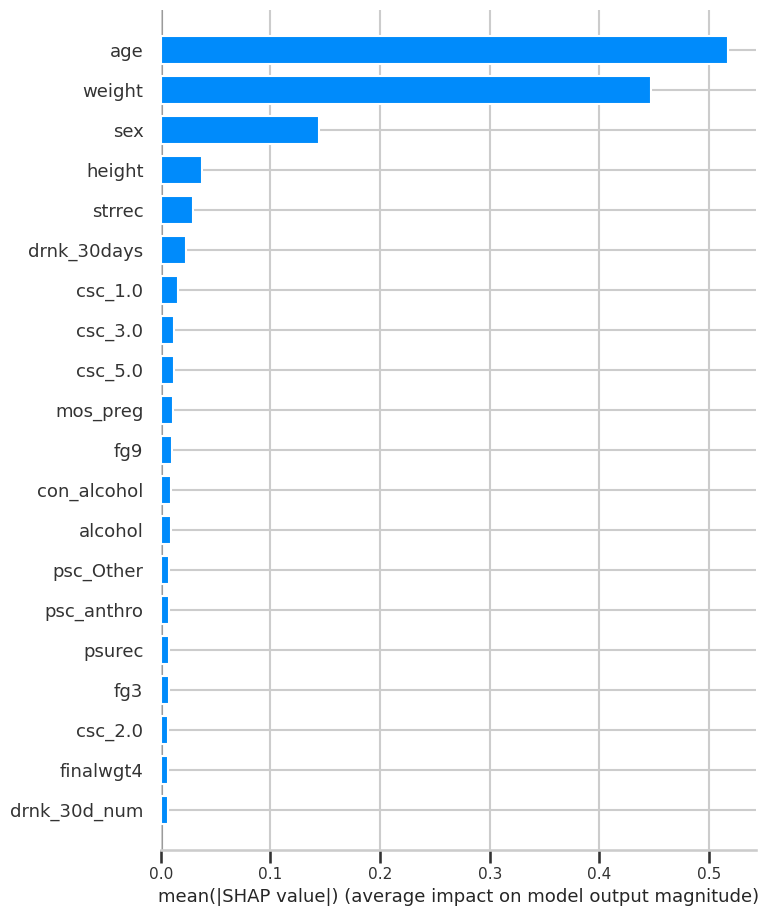

LIME explanation for test sample 0:
[('age <= -0.85', -0.27285567785624276), ('psc_Other <= 0.00', 0.09992861294271316), ('csc_Other <= 0.00', -0.07051839544188229), ('ever_smk_2.0 <= 0.00', -0.04609168301294966), ('psc_10.0 <= 0.00', -0.036020962106576855), ('psc_11.0 <= 0.00', 0.03484166545812993), ('-0.11 < weight <= 0.58', 0.03151220146011702), ('ever_smk_Other <= 0.00', 0.029295377658456277), ('ever_smk_4.0 <= 0.00', 0.027182645282574098), ('ethnicity_Other <= 0.00', 0.00927855317801841)]
Falling back to HTML display because show_in_notebook failed: ImportError: cannot import name 'display' from 'IPython.core.display' (/opt/miniforge3/lib/python3.13/site-packages/IPython/core/display.py)


In [ ]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

best_row = final_selected_df.iloc[0]
best_config_name = best_row['config_name']
best_bundle = fitted_models[best_config_name]
best_model = best_bundle['estimator']

feature_names = list(keep_num_cols)
if cat_cols:
    feature_names.extend(ohe.get_feature_names_out(cat_cols).tolist())

print('Best calibrated configuration:')
display(best_row.to_frame().T)

print('Calibration leaderboard for the selected model:')
display(calibration_df[calibration_df['config_name'] == best_config_name])

# SHAP explanation on a small sample for speed.
shap_sample = X_test_dense[:300]
shap_explainer = shap.TreeExplainer(best_model)
shap_values = shap_explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=False, plot_type='bar')
plt.tight_layout()
plt.show()

# LIME explanation for one test example.
lime_explainer = LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=feature_names,
    class_names=['No hypertension', 'Hypertension'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
 )

def lime_predict_fn(rows):
    rows = np.asarray(rows)
    probabilities = sanitize_probabilities(best_model.predict_proba(rows)[:, 1])
    return np.column_stack([1.0 - probabilities, probabilities])

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_dense[0],
    predict_fn=lime_predict_fn,
    num_features=10,
 )

print('LIME explanation for test sample 0:')
print(lime_exp.as_list())

# Work around LIME/IPython incompatibility in some environments.
try:
    lime_exp.show_in_notebook(show_table=True, show_all=False)
except Exception as e:
    from IPython.display import display, HTML
    print(f'Falling back to HTML display because show_in_notebook failed: {type(e).__name__}: {e}')
    display(HTML(lime_exp.as_html()))

## Protocol Comparison: Nested CV vs Isolated Dev-Test

> This section runs two leakage-safe strategies on the same dataset with a shared untouched final holdout.

1. **Nested CV selection on development pool** + final holdout evaluation
2. **Isolated dev-test selection on development pool** + final holdout evaluation
3. Final side-by-side comparison table from one cell

In [ ]:
import ast
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from IPython.display import display

# =========================
# Config (adjust as needed)
# =========================
comparison_random_state = 2026
final_holdout_size = 0.10
nested_outer_splits = 5
nested_inner_splits = 5
nested_n_iter = 40
isolated_inner_splits = 5
isolated_n_iter = 60
isolated_top_k = 20

# Use a compact but representative search set for tractable runtime.
comparison_model_families = ['RandomForest_GPU_XGBRF', 'XGBoost_GPU', 'CatBoost_GPU', 'LightGBM_GPU']
comparison_balance_methods = ['base', 'classweights', 'smote', 'adasyn', 'smote_cw', 'adasyn_cw']


def _infer_num_cat_columns(df_local):
    num_cols_local = [
        c for c in df_local.columns
        if pd.api.types.is_numeric_dtype(df_local[c]) or pd.api.types.is_bool_dtype(df_local[c])
    ]
    cat_cols_local = [c for c in df_local.columns if c not in num_cols_local]
    return num_cols_local, cat_cols_local


def fit_preprocessing_bundle(X_train_raw, corr_threshold=0.70):
    num_cols_local, cat_cols_local = _infer_num_cat_columns(X_train_raw)

    if num_cols_local:
        X_train_num = X_train_raw[num_cols_local].apply(pd.to_numeric, errors='coerce')
        scaler_local = StandardScaler()
        X_train_num_scaled = pd.DataFrame(
            scaler_local.fit_transform(X_train_num),
            columns=num_cols_local,
            index=X_train_raw.index,
        )

        knn_local = KNNImputer(n_neighbors=5, weights='distance')
        X_train_num_imp = pd.DataFrame(
            knn_local.fit_transform(X_train_num_scaled),
            columns=num_cols_local,
            index=X_train_raw.index,
        )

        corr = X_train_num_imp.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop_corr_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]
        keep_num_cols = [c for c in num_cols_local if c not in drop_corr_cols]
    else:
        scaler_local = None
        knn_local = None
        keep_num_cols = []

    if cat_cols_local:
        cat_imputer_local = SimpleImputer(strategy='most_frequent')
        X_train_cat = pd.DataFrame(
            cat_imputer_local.fit_transform(X_train_raw[cat_cols_local]),
            columns=cat_cols_local,
            index=X_train_raw.index,
        ).astype(str)
        ohe_local = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
        ohe_local.fit(X_train_cat)
    else:
        cat_imputer_local = None
        ohe_local = None

    return {
        'num_cols': num_cols_local,
        'cat_cols': cat_cols_local,
        'keep_num_cols': keep_num_cols,
        'scaler': scaler_local,
        'knn_imputer': knn_local,
        'cat_imputer': cat_imputer_local,
        'ohe': ohe_local,
    }


def transform_with_bundle(X_raw, bundle):
    num_block = sparse.csr_matrix((len(X_raw), 0))
    cat_block = sparse.csr_matrix((len(X_raw), 0))

    if bundle['keep_num_cols']:
        X_num = X_raw[bundle['num_cols']].apply(pd.to_numeric, errors='coerce')
        X_num_scaled = pd.DataFrame(
            bundle['scaler'].transform(X_num),
            columns=bundle['num_cols'],
            index=X_raw.index,
        )
        X_num_imp = pd.DataFrame(
            bundle['knn_imputer'].transform(X_num_scaled),
            columns=bundle['num_cols'],
            index=X_raw.index,
        )
        X_num_final = X_num_imp[bundle['keep_num_cols']]
        num_block = sparse.csr_matrix(X_num_final.values)

    if bundle['cat_cols']:
        X_cat = pd.DataFrame(
            bundle['cat_imputer'].transform(X_raw[bundle['cat_cols']]),
            columns=bundle['cat_cols'],
            index=X_raw.index,
        ).astype(str)
        cat_block = bundle['ohe'].transform(X_cat)

    X_proc = hstack([num_block, cat_block], format='csr')
    return dense_matrix(X_proc)


def evaluate_predictions(y_true, y_prob, threshold):
    y_prob = sanitize_probabilities(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'log_loss': float(log_loss(y_true, y_prob)),
        'ece': float(expected_calibration_error(y_true, y_prob)),
    }


def evaluate_candidate_inner_cv(X_dev, y_dev, candidate, n_splits=3, random_state=42):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []

    for inner_train_idx, inner_val_idx in cv.split(X_dev, y_dev):
        X_inner_train = X_dev.iloc[inner_train_idx].copy()
        y_inner_train = y_dev.iloc[inner_train_idx].values
        X_inner_val = X_dev.iloc[inner_val_idx].copy()
        y_inner_val = y_dev.iloc[inner_val_idx].values

        bundle = fit_preprocessing_bundle(X_inner_train)
        X_inner_train_proc = transform_with_bundle(X_inner_train, bundle)
        X_inner_val_proc = transform_with_bundle(X_inner_val, bundle)

        X_bal, y_bal = apply_balance_method(X_inner_train_proc, y_inner_train, candidate['balance_method'])
        use_cw = candidate['balance_method'] in {'classweights', 'adasyn_cw', 'smote_cw'}
        pos_w = positive_class_weight(y_inner_train)
        estimator = build_model(
            candidate['model_family'],
            use_class_weight=use_cw,
            pos_weight=pos_w,
            tuned_params=candidate['params'],
        )
        estimator, _ = fit_estimator(candidate['model_family'], estimator, X_bal, y_bal)

        p_val = sanitize_probabilities(estimator.predict_proba(X_inner_val_proc)[:, 1])
        fold_rows.append({
            'val_recall': recall_score(y_inner_val, (p_val >= 0.5).astype(int), zero_division=0),
            'val_accuracy': accuracy_score(y_inner_val, (p_val >= 0.5).astype(int)),
        })

    if not fold_rows:
        return None

    fold_df = pd.DataFrame(fold_rows)
    return {
        'mean_recall': float(fold_df['val_recall'].mean()),
        'mean_accuracy': float(fold_df['val_accuracy'].mean()),
        'std_recall': float(fold_df['val_recall'].std(ddof=0)),
        'std_accuracy': float(fold_df['val_accuracy'].std(ddof=0)),
    }


def run_inner_search(X_dev, y_dev, model_families, balance_methods, n_iter, inner_splits, random_state=42):
    search_rows = []
    best_candidate = None

    for model_family in model_families:
        search_space = get_search_space(model_family)
        sampled_params = list(ParameterSampler(search_space, n_iter=n_iter, random_state=random_state))

        for balance_method in balance_methods:
            for params in sampled_params:
                candidate = {
                    'model_family': model_family,
                    'balance_method': balance_method,
                    'params': params,
                }
                try:
                    scores = evaluate_candidate_inner_cv(
                        X_dev=X_dev,
                        y_dev=y_dev,
                        candidate=candidate,
                        n_splits=inner_splits,
                        random_state=random_state,
                    )
                    if scores is None:
                        continue

                    row = {
                        'model_family': model_family,
                        'balance_method': balance_method,
                        'params': params,
                        **scores,
                    }
                    search_rows.append(row)

                    if best_candidate is None:
                        best_candidate = row
                    else:
                        better = (
                            row['mean_recall'] > best_candidate['mean_recall']
                            or (
                                row['mean_recall'] == best_candidate['mean_recall']
                                and row['mean_accuracy'] > best_candidate['mean_accuracy']
                            )
                        )
                        if better:
                            best_candidate = row
                except Exception as e:
                    print(
                        f"[search] skip {model_family} + {balance_method} due to {type(e).__name__}: {e}"
                    )

    if not search_rows:
        raise RuntimeError('Inner search failed: no successful candidates.')

    search_df = pd.DataFrame(search_rows).sort_values(
        ['mean_recall', 'mean_accuracy', 'std_recall', 'std_accuracy'],
        ascending=[False, False, True, True],
    )
    return best_candidate, search_df


def fit_base_model(X_train_raw, y_train, candidate):
    bundle = fit_preprocessing_bundle(X_train_raw)
    X_train_proc = transform_with_bundle(X_train_raw, bundle)
    X_bal, y_bal = apply_balance_method(X_train_proc, y_train.values, candidate['balance_method'])
    use_cw = candidate['balance_method'] in {'classweights', 'adasyn_cw', 'smote_cw'}
    pos_w = positive_class_weight(y_train.values)
    estimator = build_model(
        candidate['model_family'],
        use_class_weight=use_cw,
        pos_weight=pos_w,
        tuned_params=candidate['params'],
    )
    estimator, device_used = fit_estimator(candidate['model_family'], estimator, X_bal, y_bal)
    return estimator, bundle, device_used


def fit_calibration_and_threshold(estimator, X_cal_proc, y_cal, random_state=42):
    if len(np.unique(y_cal)) < 2 or len(y_cal) < 20:
        return {
            'calibration_method': 'identity_no_calibration',
            'predictor': lambda p: sanitize_probabilities(p),
            'threshold': 0.5,
            'calibration_val_ece': np.nan,
            'calibration_val_log_loss': np.nan,
        }

    idx = np.arange(len(y_cal))
    try:
        idx_fit, idx_eval = train_test_split(
            idx,
            test_size=0.5,
            random_state=random_state,
            stratify=y_cal,
        )
    except Exception:
        idx_fit, idx_eval = train_test_split(idx, test_size=0.5, random_state=random_state)

    p_fit_raw = sanitize_probabilities(estimator.predict_proba(X_cal_proc[idx_fit])[:, 1])
    p_eval_raw = sanitize_probabilities(estimator.predict_proba(X_cal_proc[idx_eval])[:, 1])
    y_fit = y_cal[idx_fit]
    y_eval = y_cal[idx_eval]

    calibrators = fit_calibrators(y_fit, p_fit_raw)
    calibrators['identity'] = lambda p: sanitize_probabilities(p)

    cal_rows = []
    for cal_name, predictor in calibrators.items():
        try:
            p_eval_cal = sanitize_probabilities(np.asarray(predictor(p_eval_raw)).reshape(-1))
            cal_rows.append({
                'calibration_method': cal_name,
                'val_ece': expected_calibration_error(y_eval, p_eval_cal),
                'val_log_loss': log_loss(y_eval, p_eval_cal),
                'predictor': predictor,
                'p_eval_cal': p_eval_cal,
            })
        except Exception as e:
            print(f"[calibration] skip {cal_name}: {type(e).__name__}: {e}")

    if not cal_rows:
        return {
            'calibration_method': 'identity_no_calibration',
            'predictor': lambda p: sanitize_probabilities(p),
            'threshold': 0.5,
            'calibration_val_ece': np.nan,
            'calibration_val_log_loss': np.nan,
        }

    cal_df = pd.DataFrame(cal_rows).sort_values(['val_ece', 'val_log_loss'], ascending=[True, True])
    best = cal_df.iloc[0]
    best_threshold = choose_operating_threshold(y_eval, best['p_eval_cal'])

    return {
        'calibration_method': str(best['calibration_method']),
        'predictor': best['predictor'],
        'threshold': float(best_threshold['threshold']),
        'calibration_val_ece': float(best['val_ece']),
        'calibration_val_log_loss': float(best['val_log_loss']),
    }


def train_calibrate_evaluate(
    X_train_raw, y_train, X_cal_raw, y_cal, X_eval_raw, y_eval, candidate, random_state=42
    ):
    estimator, bundle, device_used = fit_base_model(X_train_raw, y_train, candidate)
    X_cal_proc = transform_with_bundle(X_cal_raw, bundle)
    cal_info = fit_calibration_and_threshold(estimator, X_cal_proc, y_cal.values, random_state=random_state)

    X_eval_proc = transform_with_bundle(X_eval_raw, bundle)
    p_eval_raw = sanitize_probabilities(estimator.predict_proba(X_eval_proc)[:, 1])
    p_eval_cal = sanitize_probabilities(np.asarray(cal_info['predictor'](p_eval_raw)).reshape(-1))
    metric_row = evaluate_predictions(y_eval.values, p_eval_cal, cal_info['threshold'])

    out = {
        **metric_row,
        'calibration_method': cal_info['calibration_method'],
        'threshold': cal_info['threshold'],
        'calibration_val_ece': cal_info['calibration_val_ece'],
        'calibration_val_log_loss': cal_info['calibration_val_log_loss'],
        'device_used': device_used,
    }
    return out


def _compact_candidate_signature(row):
    return f"{row['model_family']}__{row['balance_method']}__{hash(str(row['params']))}"


# ======================================================
# Shared untouched final holdout for both protocols
# ======================================================
X_full = X.reset_index(drop=True).copy()
y_full = y.reset_index(drop=True).copy()

dev_idx, final_idx = train_test_split(
    np.arange(len(y_full)),
    test_size=final_holdout_size,
    random_state=comparison_random_state,
    stratify=y_full,
 )

X_dev_pool = X_full.iloc[dev_idx].reset_index(drop=True)
y_dev_pool = y_full.iloc[dev_idx].reset_index(drop=True)
X_final_holdout = X_full.iloc[final_idx].reset_index(drop=True)
y_final_holdout = y_full.iloc[final_idx].reset_index(drop=True)

print('Shared data partition for both protocols:')
print({
    'n_total': len(X_full),
    'n_dev_pool': len(X_dev_pool),
    'n_final_holdout': len(X_final_holdout),
})


# =====================================
# Protocol A: Nested CV on dev pool
# =====================================
LIGHTGBM_GPU_ENABLED = True
outer_cv = StratifiedKFold(
    n_splits=nested_outer_splits,
    shuffle=True,
    random_state=comparison_random_state,
 )

nested_outer_rows = []
nested_selected_signatures = []
nested_candidate_lookup = {}

for fold_idx, (outer_train_idx, outer_test_idx) in enumerate(outer_cv.split(X_dev_pool, y_dev_pool), start=1):
    print(f"\n[NESTED] Outer fold {fold_idx}/{nested_outer_splits}")
    X_outer_train = X_dev_pool.iloc[outer_train_idx].reset_index(drop=True)
    y_outer_train = y_dev_pool.iloc[outer_train_idx].reset_index(drop=True)
    X_outer_test = X_dev_pool.iloc[outer_test_idx].reset_index(drop=True)
    y_outer_test = y_dev_pool.iloc[outer_test_idx].reset_index(drop=True)

    best_row, fold_search_df = run_inner_search(
        X_dev=X_outer_train,
        y_dev=y_outer_train,
        model_families=comparison_model_families,
        balance_methods=comparison_balance_methods,
        n_iter=nested_n_iter,
        inner_splits=nested_inner_splits,
        random_state=comparison_random_state + fold_idx,
    )

    candidate = {
        'model_family': best_row['model_family'],
        'balance_method': best_row['balance_method'],
        'params': best_row['params'],
    }
    sig = _compact_candidate_signature(best_row)
    nested_selected_signatures.append(sig)
    nested_candidate_lookup[sig] = candidate

    # Calibration pool is carved from outer-train only.
    idx_outer = np.arange(len(y_outer_train))
    idx_model, idx_cal = train_test_split(
        idx_outer,
        test_size=0.20,
        random_state=comparison_random_state + fold_idx,
        stratify=y_outer_train,
    )

    fold_metrics = train_calibrate_evaluate(
        X_train_raw=X_outer_train.iloc[idx_model].reset_index(drop=True),
        y_train=y_outer_train.iloc[idx_model].reset_index(drop=True),
        X_cal_raw=X_outer_train.iloc[idx_cal].reset_index(drop=True),
        y_cal=y_outer_train.iloc[idx_cal].reset_index(drop=True),
        X_eval_raw=X_outer_test,
        y_eval=y_outer_test,
        candidate=candidate,
        random_state=comparison_random_state + fold_idx,
    )

    nested_outer_rows.append({
        'outer_fold': fold_idx,
        'model_family': candidate['model_family'],
        'balance_method': candidate['balance_method'],
        'params': str(candidate['params']),
        **fold_metrics,
    })
    print({
        'selected_model': candidate['model_family'],
        'selected_balance': candidate['balance_method'],
        'recall': round(fold_metrics['recall'], 4),
        'accuracy': round(fold_metrics['accuracy'], 4),
        'calibration': fold_metrics['calibration_method'],
    })

nested_outer_df = pd.DataFrame(nested_outer_rows)
display(nested_outer_df)

nested_summary = nested_outer_df[['accuracy', 'precision', 'recall', 'f1', 'ece', 'log_loss']].agg(['mean', 'std']).T
nested_summary.columns = ['nested_outer_mean', 'nested_outer_std']
print('\n[NESTED] Outer-fold summary:')
display(nested_summary)

# Pick the most frequently selected candidate across outer folds; tie-break by mean outer recall then accuracy.
nested_sig_counts = Counter(nested_selected_signatures)
nested_ranked_candidates = []
for sig, count in nested_sig_counts.items():
    candidate = nested_candidate_lookup[sig]
    subset = nested_outer_df[
        (nested_outer_df['model_family'] == candidate['model_family'])
        & (nested_outer_df['balance_method'] == candidate['balance_method'])
    ]
    nested_ranked_candidates.append({
        'signature': sig,
        'count': count,
        'mean_outer_recall': float(subset['recall'].mean()),
        'mean_outer_accuracy': float(subset['accuracy'].mean()),
    })

nested_ranked_df = pd.DataFrame(nested_ranked_candidates).sort_values(
    ['count', 'mean_outer_recall', 'mean_outer_accuracy'],
    ascending=[False, False, False],
 )
best_nested_sig = nested_ranked_df.iloc[0]['signature']
best_nested_candidate = nested_candidate_lookup[best_nested_sig]

print('\n[NESTED] Candidate selected for final holdout:')
print({
    'model_family': best_nested_candidate['model_family'],
    'balance_method': best_nested_candidate['balance_method'],
    'params': best_nested_candidate['params'],
})

# Final holdout evaluation for nested protocol: fit/calibrate only on dev pool.
idx_dev_all = np.arange(len(y_dev_pool))
idx_dev_model, idx_dev_cal = train_test_split(
    idx_dev_all,
    test_size=0.20,
    random_state=comparison_random_state,
    stratify=y_dev_pool,
 )

nested_final_metrics = train_calibrate_evaluate(
    X_train_raw=X_dev_pool.iloc[idx_dev_model].reset_index(drop=True),
    y_train=y_dev_pool.iloc[idx_dev_model].reset_index(drop=True),
    X_cal_raw=X_dev_pool.iloc[idx_dev_cal].reset_index(drop=True),
    y_cal=y_dev_pool.iloc[idx_dev_cal].reset_index(drop=True),
    X_eval_raw=X_final_holdout,
    y_eval=y_final_holdout,
    candidate=best_nested_candidate,
    random_state=comparison_random_state,
 )

nested_final_row = {
    'protocol': 'nested_cv_plus_final_holdout',
    'selected_model_family': best_nested_candidate['model_family'],
    'selected_balance_method': best_nested_candidate['balance_method'],
    'selected_params': str(best_nested_candidate['params']),
    **nested_final_metrics,
}


# ===================================================
# Protocol B: Isolated dev-test on dev pool
# ===================================================
LIGHTGBM_GPU_ENABLED = True

idx_dev = np.arange(len(y_dev_pool))
idx_train_sub, idx_dev_test_sub = train_test_split(
    idx_dev,
    test_size=0.20,
    random_state=comparison_random_state,
    stratify=y_dev_pool,
 )

X_train_sub = X_dev_pool.iloc[idx_train_sub].reset_index(drop=True)
y_train_sub = y_dev_pool.iloc[idx_train_sub].reset_index(drop=True)
X_dev_test_sub = X_dev_pool.iloc[idx_dev_test_sub].reset_index(drop=True)
y_dev_test_sub = y_dev_pool.iloc[idx_dev_test_sub].reset_index(drop=True)

print('\n[ISOLATED DEV-TEST] Inner search on train_sub...')
best_isolated_inner, isolated_search_df = run_inner_search(
    X_dev=X_train_sub,
    y_dev=y_train_sub,
    model_families=comparison_model_families,
    balance_methods=comparison_balance_methods,
    n_iter=isolated_n_iter,
    inner_splits=isolated_inner_splits,
    random_state=comparison_random_state,
 )

isolated_top_df = isolated_search_df.head(isolated_top_k).copy()
print('[ISOLATED DEV-TEST] Top candidates carried to dev-test selection:')
display(isolated_top_df[['model_family', 'balance_method', 'mean_recall', 'mean_accuracy', 'params']])

isolated_selection_rows = []

for cand_idx, cand_row in isolated_top_df.iterrows():
    candidate = {
        'model_family': cand_row['model_family'],
        'balance_method': cand_row['balance_method'],
        'params': cand_row['params'],
    }

    # Fit on train_sub; calibrate/threshold selection on isolated dev-test split only.
    idx_dt = np.arange(len(y_dev_test_sub))
    idx_dt_fit, idx_dt_eval = train_test_split(
        idx_dt,
        test_size=0.5,
        random_state=comparison_random_state + int(cand_idx),
        stratify=y_dev_test_sub,
    )

    metrics_dt = train_calibrate_evaluate(
        X_train_raw=X_train_sub,
        y_train=y_train_sub,
        X_cal_raw=X_dev_test_sub.iloc[idx_dt_fit].reset_index(drop=True),
        y_cal=y_dev_test_sub.iloc[idx_dt_fit].reset_index(drop=True),
        X_eval_raw=X_dev_test_sub.iloc[idx_dt_eval].reset_index(drop=True),
        y_eval=y_dev_test_sub.iloc[idx_dt_eval].reset_index(drop=True),
        candidate=candidate,
        random_state=comparison_random_state + int(cand_idx),
    )

    isolated_selection_rows.append({
        'model_family': candidate['model_family'],
        'balance_method': candidate['balance_method'],
        'params': str(candidate['params']),
        **metrics_dt,
    })

isolated_selection_df = pd.DataFrame(isolated_selection_rows).sort_values(
    ['recall', 'accuracy', 'f1', 'ece', 'log_loss'],
    ascending=[False, False, False, True, True],
 )
print('\n[ISOLATED DEV-TEST] Candidate ranking on isolated dev-test:')
display(isolated_selection_df)

best_isolated_row = isolated_selection_df.iloc[0]
best_isolated_candidate = {
    'model_family': best_isolated_row['model_family'],
    'balance_method': best_isolated_row['balance_method'],
    'params': ast.literal_eval(best_isolated_row['params']),
}

print('\n[ISOLATED DEV-TEST] Candidate selected for final holdout:')
print(best_isolated_candidate)

# Final holdout evaluation: refit on train_sub only; calibrate on isolated dev-test fit split.
idx_dt = np.arange(len(y_dev_test_sub))
idx_dt_fit, _ = train_test_split(
    idx_dt,
    test_size=0.5,
    random_state=comparison_random_state,
    stratify=y_dev_test_sub,
 )

isolated_final_metrics = train_calibrate_evaluate(
    X_train_raw=X_train_sub,
    y_train=y_train_sub,
    X_cal_raw=X_dev_test_sub.iloc[idx_dt_fit].reset_index(drop=True),
    y_cal=y_dev_test_sub.iloc[idx_dt_fit].reset_index(drop=True),
    X_eval_raw=X_final_holdout,
    y_eval=y_final_holdout,
    candidate=best_isolated_candidate,
    random_state=comparison_random_state,
 )

isolated_final_row = {
    'protocol': 'isolated_dev_test_plus_final_holdout',
    'selected_model_family': best_isolated_candidate['model_family'],
    'selected_balance_method': best_isolated_candidate['balance_method'],
    'selected_params': str(best_isolated_candidate['params']),
    **isolated_final_metrics,
}


# =========================
# Final one-cell comparison
# =========================
protocol_comparison_df = pd.DataFrame([nested_final_row, isolated_final_row])
protocol_comparison_df = protocol_comparison_df[[
    'protocol',
    'selected_model_family',
    'selected_balance_method',
    'calibration_method',
    'threshold',
    'accuracy',
    'precision',
    'recall',
    'f1',
    'ece',
    'log_loss',
    'selected_params',
]]
protocol_comparison_df = protocol_comparison_df.sort_values(
    ['recall', 'accuracy', 'f1', 'ece', 'log_loss'],
    ascending=[False, False, False, True, True],
 ).reset_index(drop=True)

print('\nFinal comparison on the same untouched final holdout:')
display(protocol_comparison_df)

protocol_dir = Path.cwd() / 'gpu_only_tree_models_artifacts' / 'protocol_comparison'
protocol_dir.mkdir(parents=True, exist_ok=True)
nested_outer_df.to_csv(protocol_dir / 'nested_outer_fold_metrics.csv', index=False)
nested_summary.to_csv(protocol_dir / 'nested_outer_summary.csv', index=True)
isolated_selection_df.to_csv(protocol_dir / 'isolated_dev_test_selection_metrics.csv', index=False)
protocol_comparison_df.to_csv(protocol_dir / 'final_protocol_comparison_on_shared_holdout.csv', index=False)

print(f'Saved protocol-comparison artifacts to: {protocol_dir}')

Shared data partition for both protocols:
{'n_total': 93429, 'n_dev_pool': 84086, 'n_final_holdout': 9343}

[NESTED] Outer fold 1/3
